# TRABAJO FINAL
El trabajo final consiste en el aprendizaje automatico de un robot movil para detectar la superficie por la que se desplaza contando unicamente de los sensores internos (odometria y sensores inerciales).

Existen 9 tipos de superficie:
- Alfombra
- Baldosa
- Madera
- Grava
- Hormigon
- Asfalto
- Hielo
- Arena
- Hierba



## 1. Carga de librerias
Se realiza la carga de las librerias mas importantes en cuanto a tratamiento de datos, visualizacion y maching learning

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedGroupKFold
from imblearn.over_sampling import SMOTE


A continuacion se cargan los datos de Kaglee

In [ ]:
!gdown 1yWjGwmGP2E1CaRsdP1DV1ZO8XuePC7wQ

Downloading...
From (original): https://drive.google.com/uc?id=1yWjGwmGP2E1CaRsdP1DV1ZO8XuePC7wQ
From (redirected): https://drive.google.com/uc?id=1yWjGwmGP2E1CaRsdP1DV1ZO8XuePC7wQ&confirm=t&uuid=8babcc81-6b02-4245-8d8d-145737d7288d
To: /content/career-con-2019.zip
100% 36.5M/36.5M [00:00<00:00, 141MB/s] 


In [ ]:
!unzip career-con-2019.zip

Archive:  career-con-2019.zip
  inflating: X_test.csv              
  inflating: X_train.csv             
  inflating: sample_submission.csv   
  inflating: y_train.csv             


### Inspección general del dataset
En este apartado se realiza una primera inspección del dataset con el objetivo de comprender su estructura general, identificar las variables disponibles y verificar el formato en el que se presentan las mediciones.

In [ ]:
df_train = pd.read_csv("X_train.csv")
df_test =  pd.read_csv("X_test.csv")

In [ ]:
df_train.shape

(487680, 13)

In [ ]:
print(len(df_train["series_id"].unique()))
df_train["series_id"].unique()

3810


array([   0,    1,    2, ..., 3807, 3808, 3809])

In [ ]:
df_train.columns

Index(['row_id', 'series_id', 'measurement_number', 'orientation_X',
       'orientation_Y', 'orientation_Z', 'orientation_W', 'angular_velocity_X',
       'angular_velocity_Y', 'angular_velocity_Z', 'linear_acceleration_X',
       'linear_acceleration_Y', 'linear_acceleration_Z'],
      dtype='object')

In [ ]:
df_train.head(128)

,row_id,series_id,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z
0,0_0,0,0,-0.75853,-0.63435,-0.10488,-0.10597,0.107650,0.017561,0.000767,-0.74857,2.10300,-9.7532
1,0_1,0,1,-0.75853,-0.63434,-0.10490,-0.10600,0.067851,0.029939,0.003386,0.33995,1.50640,-9.4128
2,0_2,0,2,-0.75853,-0.63435,-0.10492,-0.10597,0.007275,0.028934,-0.005978,-0.26429,1.59220,-8.7267
3,0_3,0,3,-0.75852,-0.63436,-0.10495,-0.10597,-0.013053,0.019448,-0.008974,0.42684,1.09930,-10.0960
4,0_4,0,4,-0.75852,-0.63435,-0.10495,-0.10596,0.005135,0.007652,0.005245,-0.50969,1.46890,-10.4410
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,0_123,0,123,-0.75943,-0.63316,-0.10470,-0.10677,0.041741,0.012857,0.016053,-0.80827,1.79890,-6.8687
124,0_124,0,124,-0.75945,-0.63313,-0.10473,-0.10683,-0.052041,-0.014752,0.021632,-0.36055,2.35620,-6.8926
125,0_125,0,125,-0.75949,-0.63309,-0.10467,-0.10690,-0.083083,-0.044480,0.031726,-0.98193,0.97328,-9.9795
126,0_126,0,126,-0.75950,-0.63307,-0.10464,-0.10693,-0.001305,-0.031012,0.017241,-0.72591,0.34931,-11.9770


El dataset contiene mediciones de sensores organizadas en formato tabular. Cada fila representa una medición en un instante de tiempo, identificada por series_id y measurement_number

In [ ]:
print(df_test.shape)
print(len(df_test["series_id"].unique()))
df_test["series_id"].unique()

(488448, 13)
3816


array([   0,    1,    2, ..., 3813, 3814, 3815])

### Relación entre datos y etiquetas
En este apartado se estudia la relación entre las mediciones de los sensores y las etiquetas asociadas, con el fin de entender cómo se estructura el problema de clasificación.

In [ ]:
df_train_labels = pd.read_csv("y_train.csv")
df_train_labels.head()

,series_id,group_id,surface
0,0,13,fine_concrete
1,1,31,concrete
2,2,20,concrete
3,3,31,concrete
4,4,22,soft_tiles


In [ ]:
df_train_labels["surface"].unique()

array(['fine_concrete', 'concrete', 'soft_tiles', 'tiled', 'soft_pvc',
       'hard_tiles_large_space', 'carpet', 'hard_tiles', 'wood'],
      dtype=object)

Cada serie temporal tiene asociada una única etiqueta que representa el tipo de superficie.

Esto implica que el problema consiste en clasificar trayectorias completas del robot, lo que refuerza la importancia de considerar la información temporal en el proceso de modelado.

In [ ]:
df_train_labels.shape

(3810, 3)

## 2. Exploracion
En la exploración se intentará graficasr diferentes aspectos de los datos para entender el problema y como deberiá realizar el pre-procesado a partir de éstos.

### Distribucion de clases
Se analiza la distribución de las clases para identificar posibles desbalances que puedan afectar al entrenamiento de los modelos.

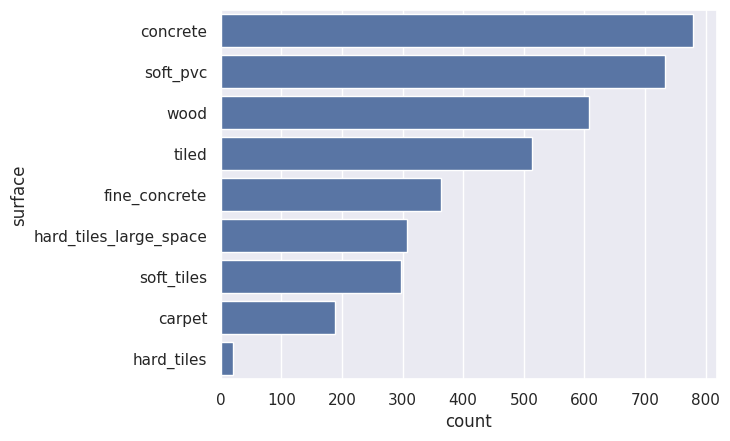

In [ ]:
sns.set(style='darkgrid')
sns.countplot(y = 'surface',
              data = df_train_labels,
              order = df_train_labels['surface'].value_counts().index)
plt.show()

Se observa un claro desbalanceo entre las clases, donde algunas superficies están significativamente más representadas que otras.

Este desbalance puede provocar que los modelos tiendan a favorecer las clases mayoritarias, por lo que será necesario tenerlo en cuenta en la fase de modelado, especialmente en la elección de métricas y posibles estrategias de compensación.

### Visualización de señales temporales
Se representan gráficamente las señales de los sensores para distintas series con el objetivo de analizar su comportamiento temporal, identificar patrones y evaluar el nivel de ruido presente en los datos.

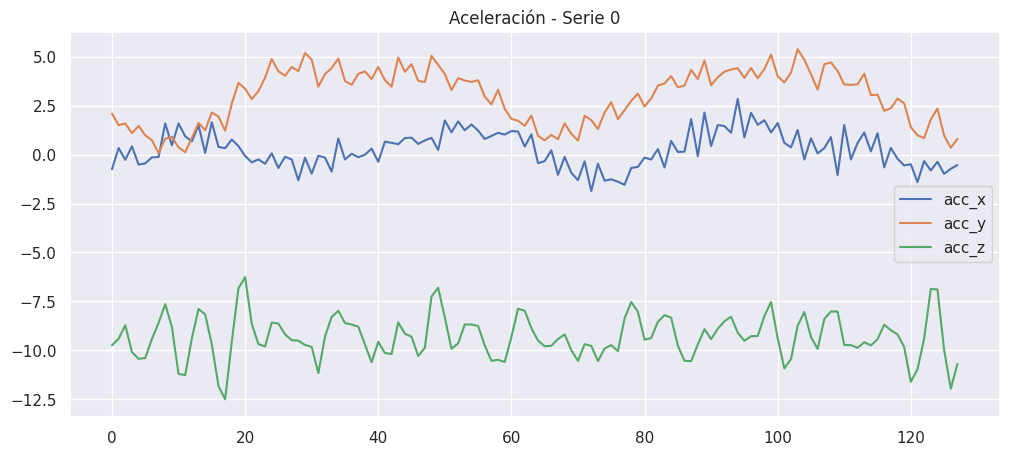

In [ ]:
serie = df_train[df_train['series_id'] == 0]

plt.figure(figsize=(12,5))
plt.plot(serie['linear_acceleration_X'], label='acc_x')
plt.plot(serie['linear_acceleration_Y'], label='acc_y')
plt.plot(serie['linear_acceleration_Z'], label='acc_z')
plt.legend()
plt.title("Aceleración - Serie 0")
plt.show()

Las señales presentan variaciones significativas a lo largo del tiempo, con patrones que reflejan el movimiento del robot.

Sin embargo, también se aprecia un nivel considerable de ruido, lo que puede dificultar la extracción directa de información relevante.

Esto sugiere que será necesario aplicar técnicas de procesamiento o transformación de las señales para facilitar el aprendizaje de los modelos.

El eje z se observa que va en torno a -10, lo que equivale a la gravedad y como la superficie amortigua (no será la misma amortiguacion la del concreto que la de la arena). Por ello, se hará un barrido entre las aceleraciones lineales de cada serie.

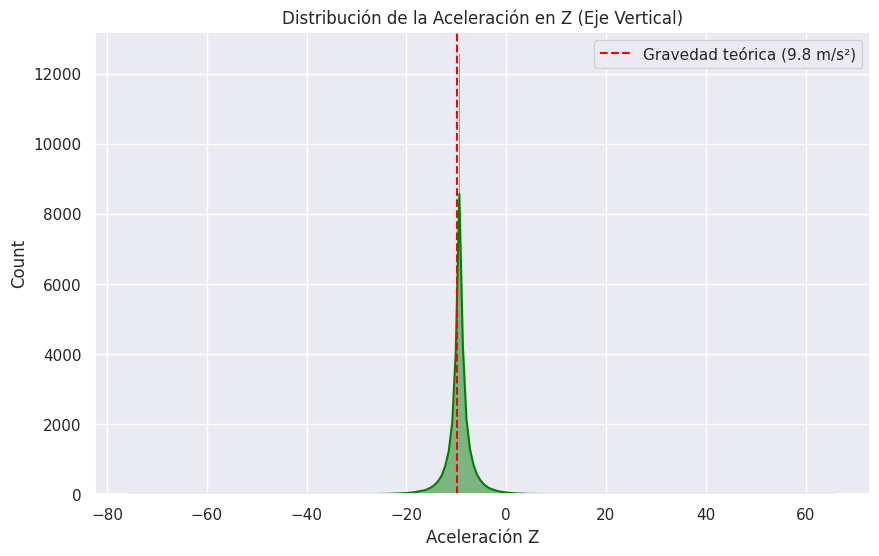

Media de Aceleración Z: -9.36


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_train['linear_acceleration_Z'], kde=True, color='green')
plt.axvline(x=-9.8, color='red', linestyle='--', label='Gravedad teórica (9.8 m/s²)')
plt.title('Distribución de la Aceleración en Z (Eje Vertical)')
plt.xlabel('Aceleración Z')
plt.legend()
plt.show()

print(f"Media de Aceleración Z: {df_train['linear_acceleration_Z'].mean():.2f}")

### Comparación entre series
Se comparan distintas series temporales con el objetivo de identificar diferencias en el comportamiento de las señales asociadas a diferentes trayectorias.

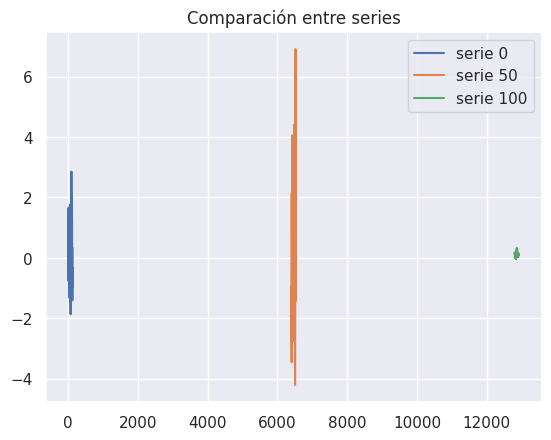

In [ ]:
serie1 = df_train[df_train['series_id'] == 0]
serie2 = df_train[df_train['series_id'] == 50]
serie3 = df_train[df_train['series_id'] == 100]
plt.plot(serie1['linear_acceleration_X'], label='serie 0')
plt.plot(serie2['linear_acceleration_X'], label='serie 50')
plt.plot(serie3['linear_acceleration_X'], label='serie 100')
plt.legend()
plt.title("Comparación entre series")
plt.show()

Al comparar diferentes series, se observan variaciones en la forma y amplitud de las señales, lo que indica que existe información discriminativa entre las trayectorias.

No obstante, estas diferencias no son triviales, lo que sugiere que la separación entre clases puede requerir modelos capaces de capturar patrones complejos y no lineales.
A continuacion se comparará una variable de dos series diferentes:

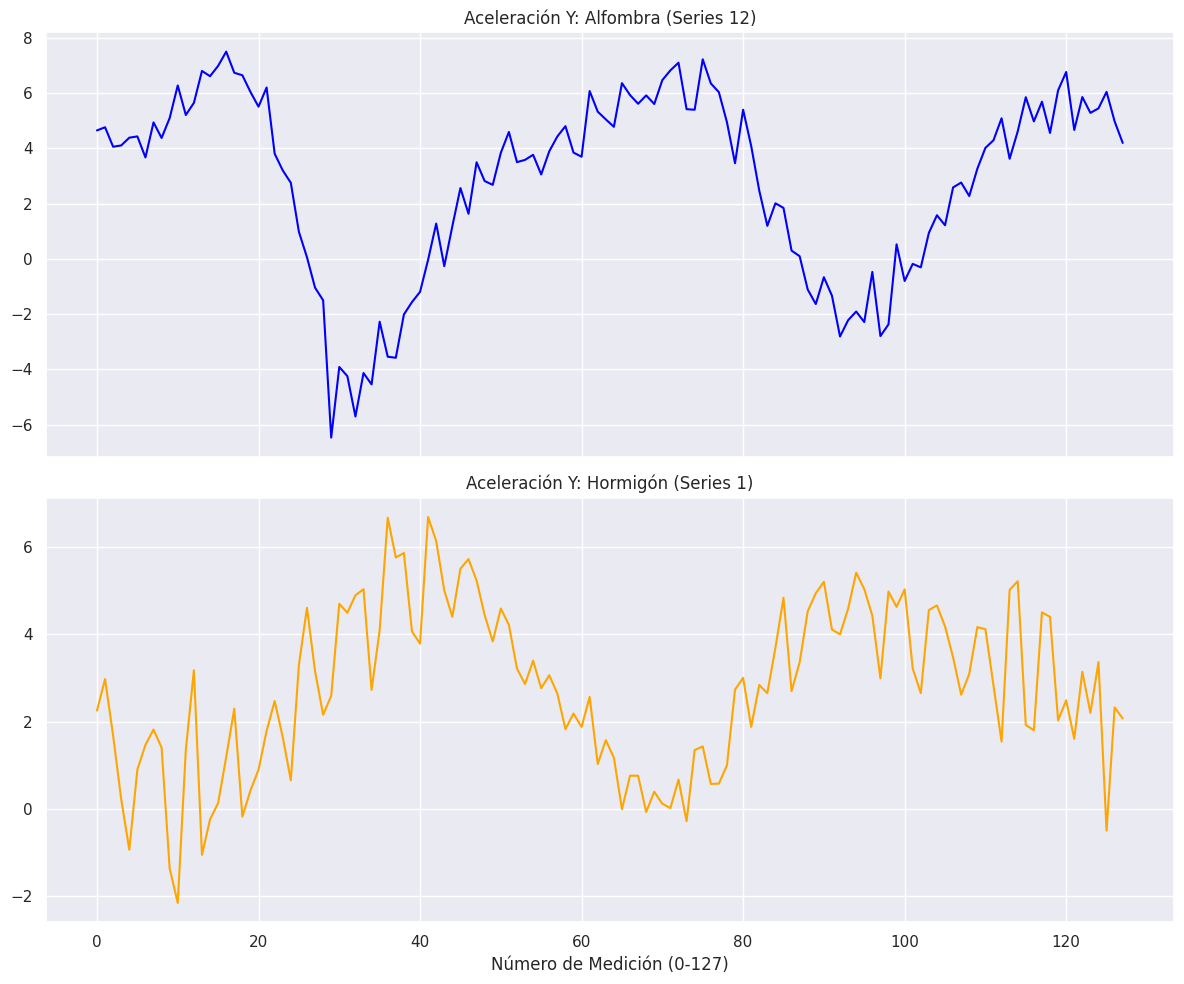

In [ ]:
id_carpet = df_train_labels[df_train_labels['surface'] == 'carpet']['series_id'].iloc[0]
id_concrete = df_train_labels[df_train_labels['surface'] == 'concrete']['series_id'].iloc[0]

serie_carpet = df_train[df_train['series_id'] == id_carpet]
serie_concrete = df_train[df_train['series_id'] == id_concrete]

fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Graficar Alfombra
ax[0].plot(serie_carpet['measurement_number'], serie_carpet['linear_acceleration_Y'], color='blue')
ax[0].set_title(f'Aceleración Y: Alfombra (Series {id_carpet})')

# Graficar Hormigón
ax[1].plot(serie_concrete['measurement_number'], serie_concrete['linear_acceleration_Y'], color='orange')
ax[1].set_title(f'Aceleración Y: Hormigón (Series {id_concrete})')

plt.xlabel('Número de Medición (0-127)')
plt.tight_layout()
plt.show()

### Boxplot por superficie

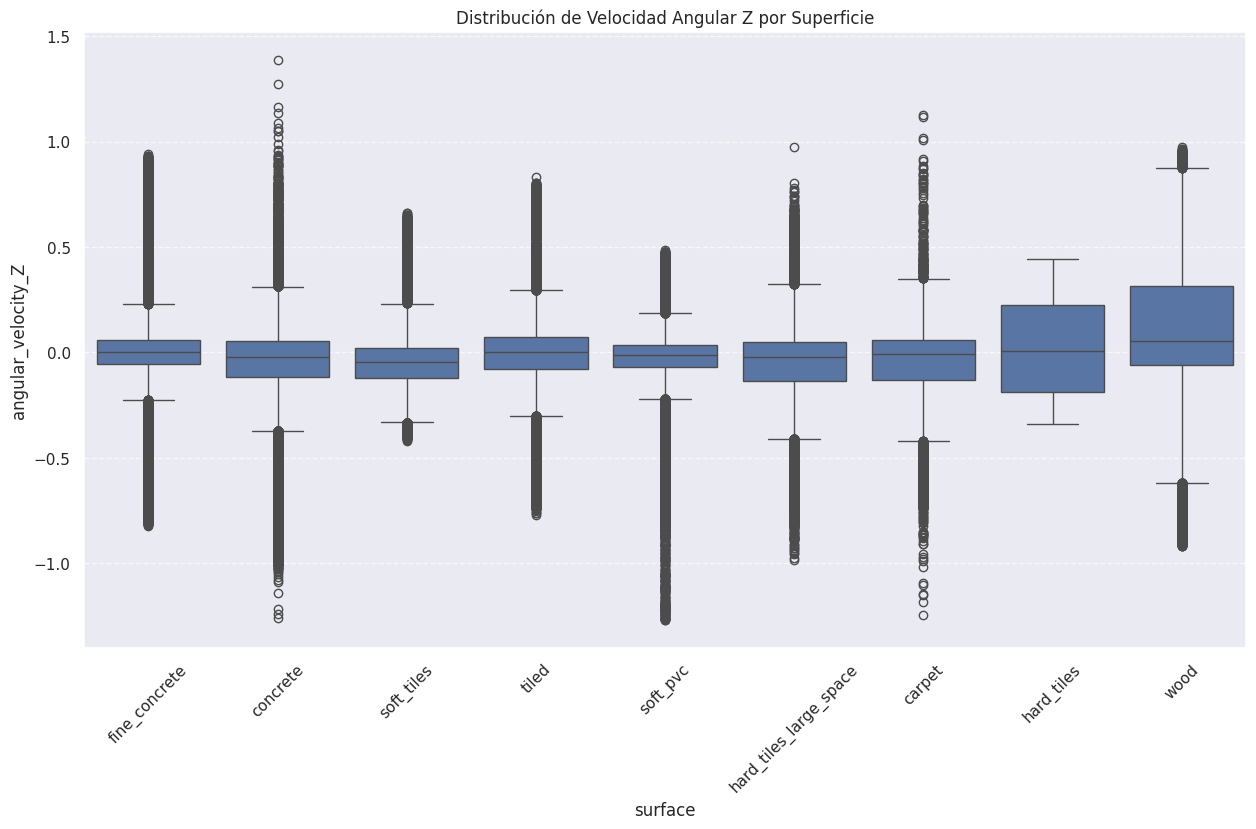

In [ ]:
df_eda = df_train.merge(df_train_labels[['series_id', 'surface']], on='series_id')

plt.figure(figsize=(15, 8))
sns.boxplot(x='surface', y='angular_velocity_Z', data=df_eda)
plt.xticks(rotation=45)
plt.title('Distribución de Velocidad Angular Z por Superficie')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

La comparación de los diagramas de caja revela que la varianza de la señal es el principal factor diferenciador entre terrenos.

Mientras que las superficies lisas como la alfombra presentan distribuciones compactas, los suelos irregulares como la grava muestran una dispersión mucho mayor, lo que confirma que la vibración mecánica es la clave para la clasificación.

La presencia masiva de valores atípicos en la aceleración no debe tratarse como ruido, sino como el registro de los impactos del robot contra las irregularidades del suelo

En consecuencia, estos resultados justifican que el preprocesamiento debe centrarse en extraer métricas de dispersión y rangos por cada serie, ya que los valores medios por sí solos no capturan la rugosidad característica de cada superficie.

* series distribution

In [ ]:
df_train.series_id.value_counts()

,count
series_id,
3809,128
0,128
3793,128
3792,128
3791,128
...,...
6,128
5,128
4,128


In [ ]:
(df_train.series_id.value_counts() == 128).sum() == len(df_train_labels)

np.True_

### Correlación
Se estudian las correlaciones entre las variables para identificar posibles relaciones o redundancias entre los sensores.

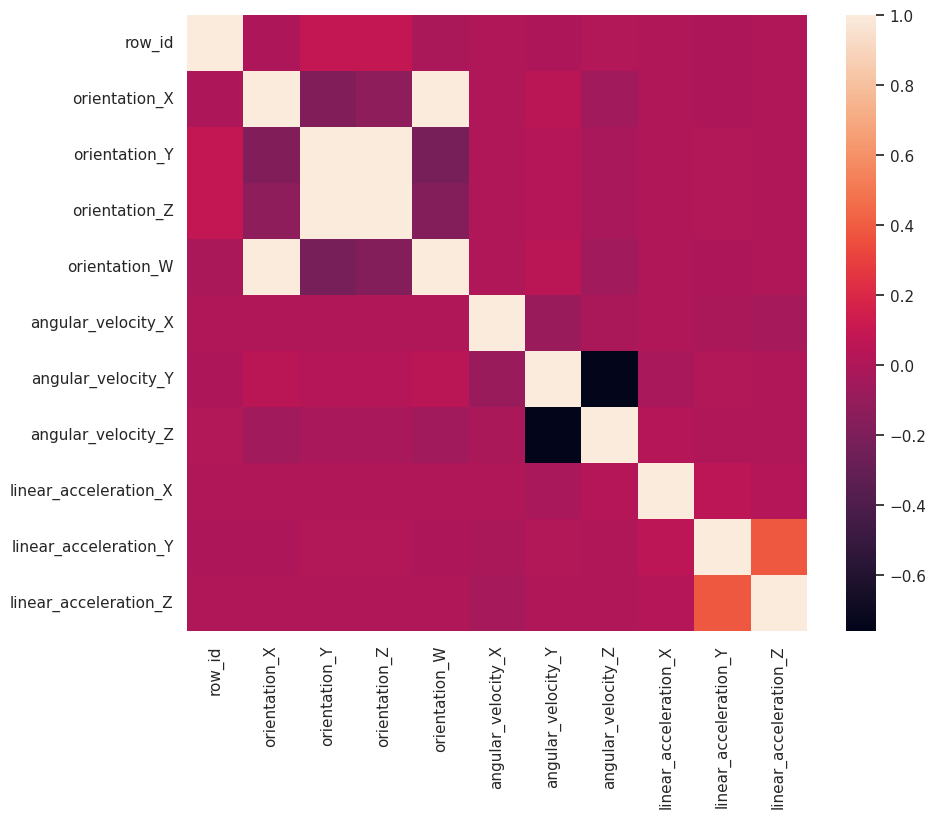

In [ ]:
corr = df_train.drop(['series_id','measurement_number'], axis=1).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr)
plt.show()

Se observa una fuerte correlacion en los cuaternios. Esto se debe a que los cuaterniones son una forma de representar la orientación en el espacio 3D. El hecho de que estén tan correlacionados indica que el robot se movió siguiendo patrones muy específicos (quizás líneas rectas o giros constantes).

La orientación absoluta (donde apunta el robot) no debería definir la superficie. Si el robot va hacia el Norte en cemento o hacia el Sur en cemento, la superficie es la misma.

Los cuaterniones podrían descartarse o transformarse, centrándose más en la aceleración y velocidad angular, que son las que tienen correlaciones más bajas entre sí.

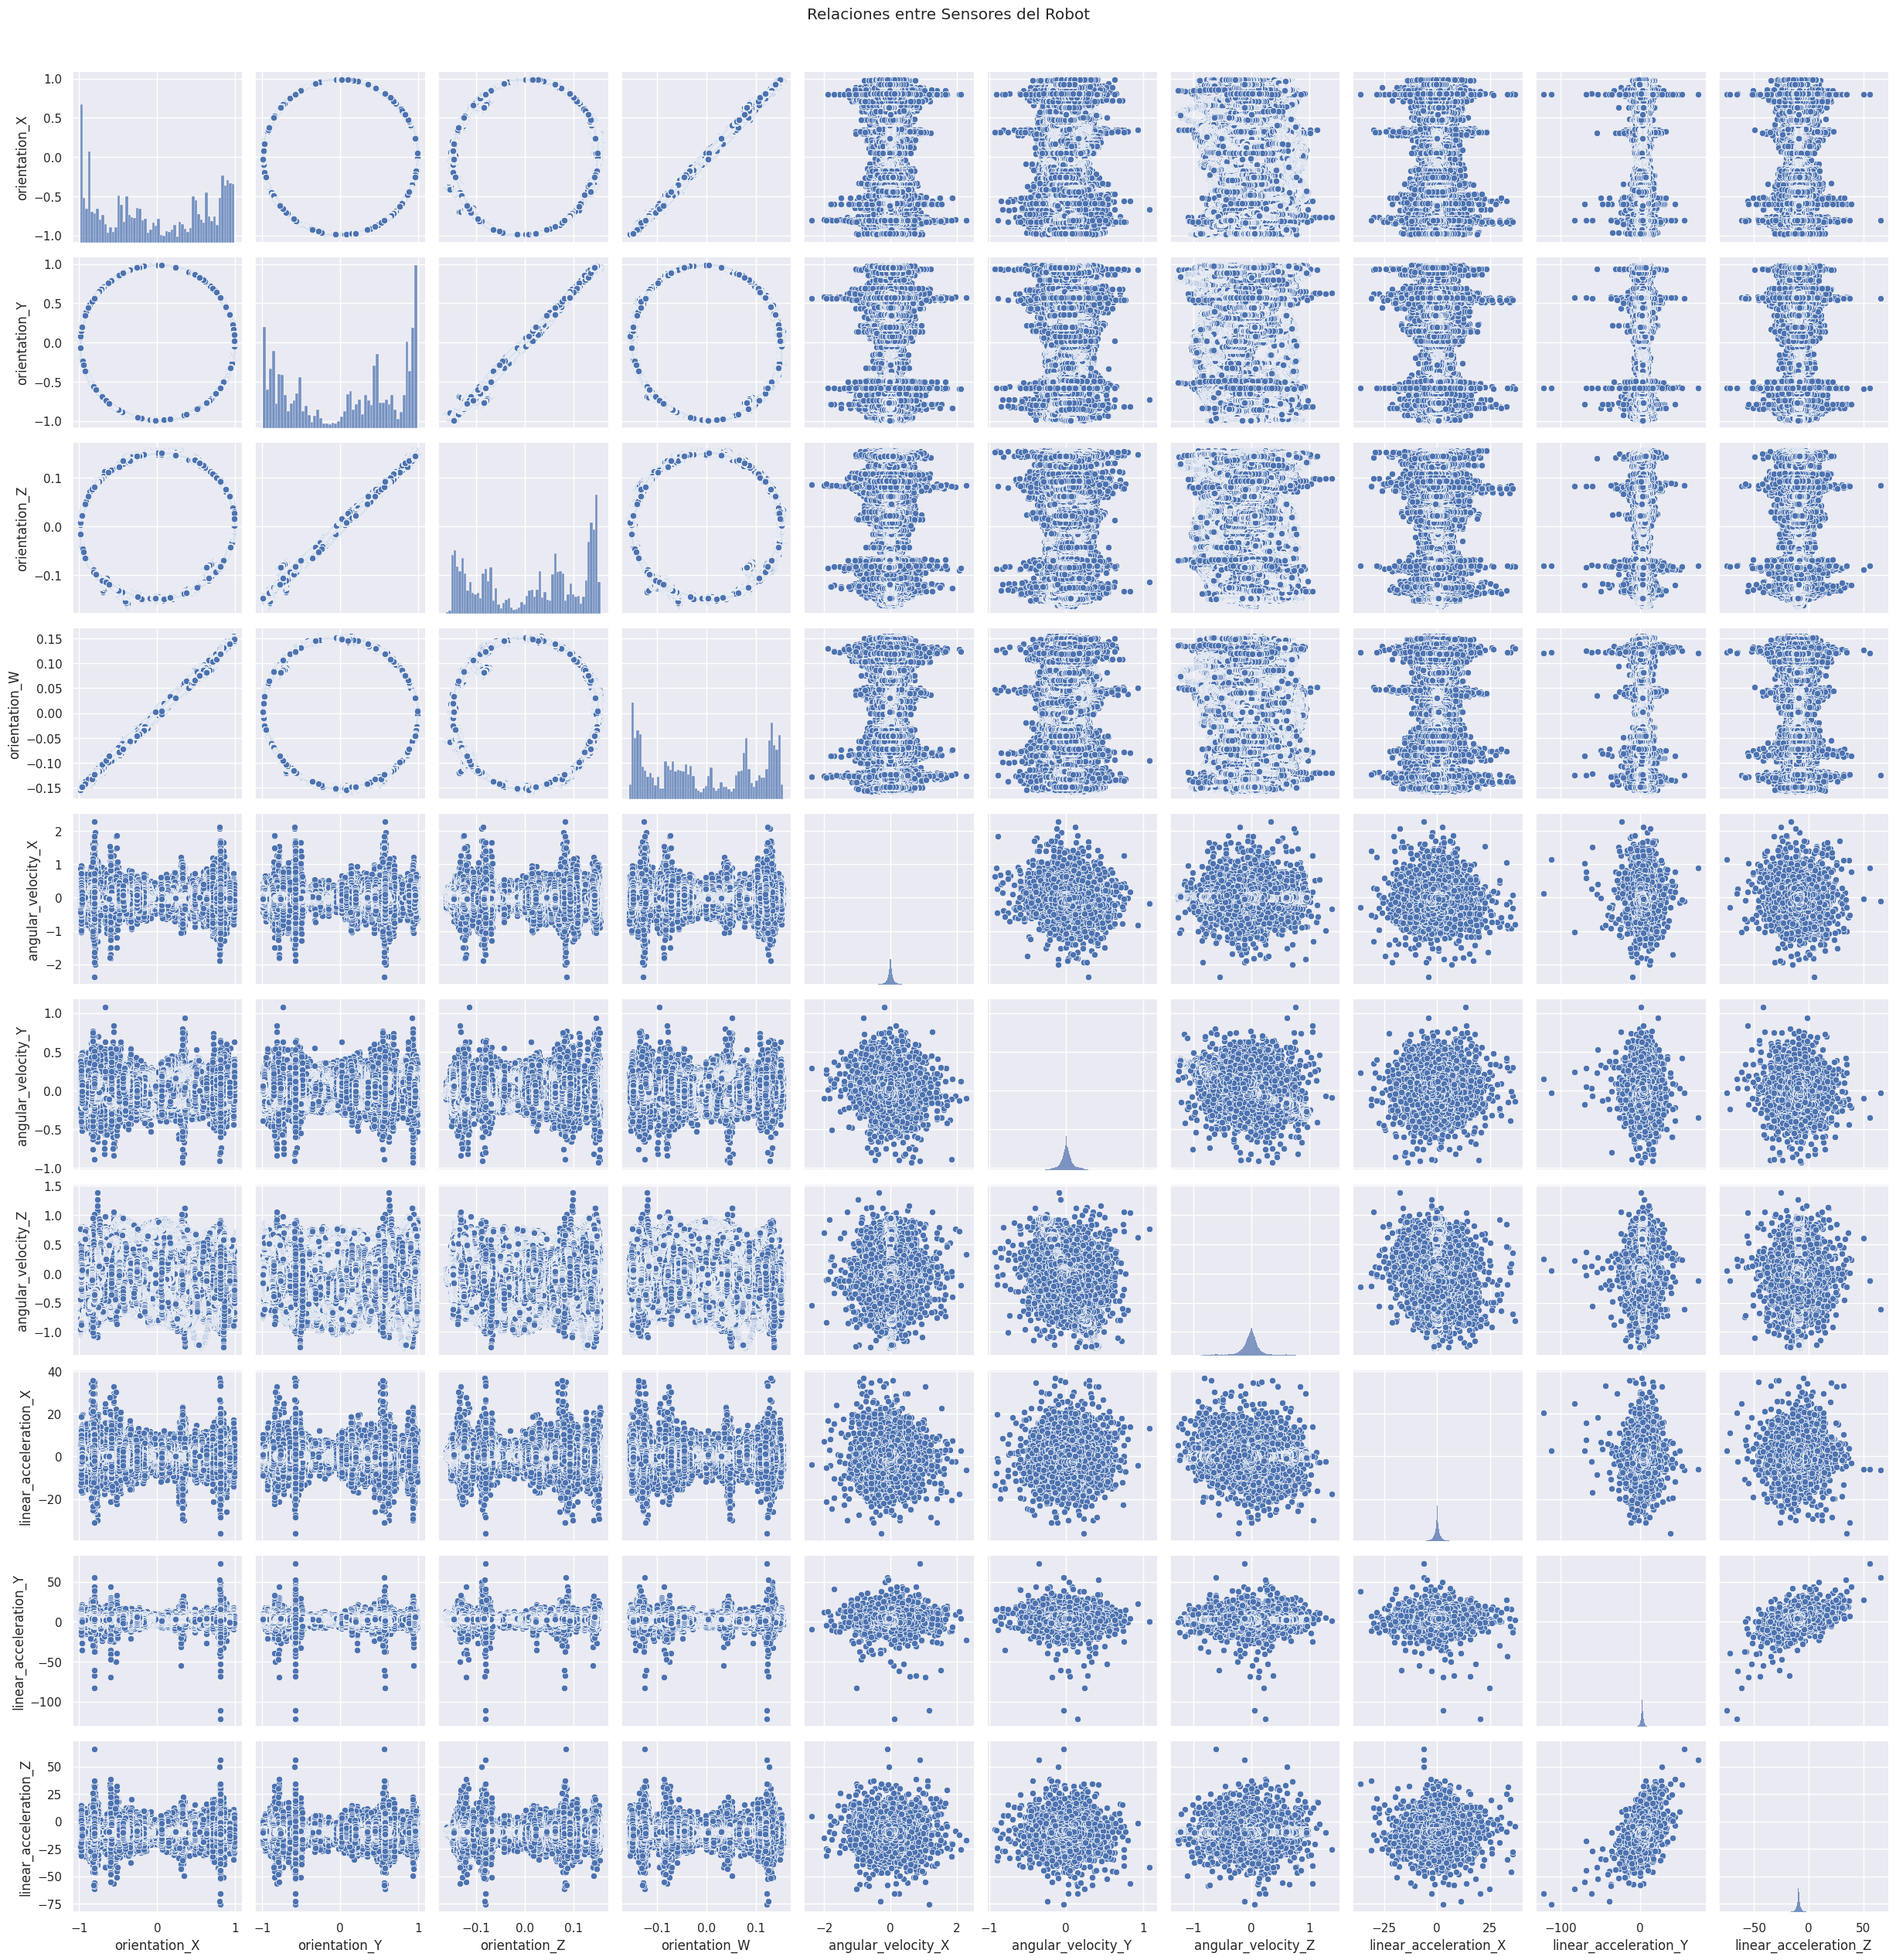

In [ ]:
sensores_robot = [
    'orientation_X', 'orientation_Y', 'orientation_Z', 'orientation_W',
    'angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z',
    'linear_acceleration_X', 'linear_acceleration_Y', 'linear_acceleration_Z'
]

sns.pairplot(df_train[sensores_robot], height=2.5)
plt.suptitle('Relaciones entre Sensores del Robot', y=1.02)
plt.show()

El análisis de la matriz de dispersión (pairplot) de los 10 sensores inerciales permite extraer las siguientes conclusiones:

- Correlación Geométrica: Las variables de orientación presentan una dependencia
estructural muy alta, formando figuras geométricas definidas. Esto confirma que los cuaterniones contienen información redundante que podría simplificarse en pasos posteriores.

- Desacoplamiento de Señales Dinámicas: A diferencia de la orientación, las velocidades angulares y las aceleraciones lineales no muestran una correlación lineal clara entre sí. Esta independencia es positiva para el modelo, ya que cada sensor aporta información única sobre la interacción del robot con el suelo.

- Naturaleza de los Datos: Los histogramas de aceleración muestran una alta concentración de valores cercanos a cero con una presencia notable de valores extremos (colas pesadas). Esto valida la hipótesis de que la discriminación de superficies dependerá de la capacidad del modelo para interpretar estos picos de vibración y no solo los valores promedio.

Como conclusion, el análisis exploratorio confirma que los datos capturados por los sensores IMU reflejan fielmente la textura del terreno a través de la vibración.

Se ha identificado un fuerte desbalanceo de clases que condicionará la métrica de evaluación hacia el F1-Score, y una alta redundancia en las variables de orientación (cuaterniones) que sugiere que la información crítica reside más en la dinámica del movimiento que en la dirección absoluta.

La presencia de picos de aceleración en superficies rugosas valida que la distinción entre suelos no depende de valores promedio, sino de la variabilidad y el rango de las señales dentro de cada ventana de tiempo.

## Preprocesado
Tras comprender la naturaleza de las señales, el preprocesado se enfocará en transformar las series temporales de 128 muestras en un formato apto para algoritmos de clasificación tradicionales.

Dado que el modelo debe predecir una única superficie por cada series_id, el objetivo principal es la reducción de dimensionalidad mediante la extracción de características estadísticas.

Este paso es fundamental para eliminar el ruido de alta frecuencia y resumir el comportamiento físico del robot en variables representativas de su estabilidad y vibración.

### Output

Conversión de las clases de superficie (texto) a valores numéricos mediante LabelEncoder, permitiendo que el algoritmo realice cálculos matemáticos para la clasificación.

In [ ]:
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(df_train_labels.surface)
print(np.unique(encoded_labels))
print(label_encoder.classes_)
df_train_labels["labels"] = encoded_labels
df_train_labels.head()

[0 1 2 3 4 5 6 7 8]
['carpet' 'concrete' 'fine_concrete' 'hard_tiles' 'hard_tiles_large_space'
 'soft_pvc' 'soft_tiles' 'tiled' 'wood']


,series_id,group_id,surface,labels
0,0,13,fine_concrete,2
1,1,31,concrete,1
2,2,20,concrete,1
3,3,31,concrete,1
4,4,22,soft_tiles,6


### Input

Transformación de las 128 mediciones temporales en un vector único de 1280 columnas por trayectoria. Esto permite que el modelo procese toda la serie temporal como una sola fila de datos.

In [ ]:
features = df_train.columns.to_list()[3:]
features

['orientation_X',
 'orientation_Y',
 'orientation_Z',
 'orientation_W',
 'angular_velocity_X',
 'angular_velocity_Y',
 'angular_velocity_Z',
 'linear_acceleration_X',
 'linear_acceleration_Y',
 'linear_acceleration_Z']

* Create the rows for each serie

In [ ]:
# Pivot the DataFrame
df_pivot = df_train.pivot_table(index='series_id',
                          columns='measurement_number',
                          values=['orientation_X', 'orientation_Y', 'orientation_Z', 'orientation_W',
                                  'angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z',
                                  'linear_acceleration_X', 'linear_acceleration_Y', 'linear_acceleration_Z'],
                          aggfunc='mean')

# Flatten the multi-level columns after pivoting
df_pivot.columns = ['{}_{}'.format(var, num) for var, num in df_pivot.columns]


In [ ]:
df_pivot.head()

,angular_velocity_X_0,angular_velocity_X_1,angular_velocity_X_2,angular_velocity_X_3,angular_velocity_X_4,angular_velocity_X_5,angular_velocity_X_6,angular_velocity_X_7,angular_velocity_X_8,angular_velocity_X_9,...,orientation_Z_118,orientation_Z_119,orientation_Z_120,orientation_Z_121,orientation_Z_122,orientation_Z_123,orientation_Z_124,orientation_Z_125,orientation_Z_126,orientation_Z_127
series_id,,,,,,,,,,,,,,,,,,,,,
0,0.107650,0.067851,0.007275,-0.013053,0.005135,0.059664,0.082140,0.056218,-0.012846,-0.090082,...,-0.105070,-0.105060,-0.105010,-0.104830,-0.104720,-0.104700,-0.104730,-0.104670,-0.104640,-0.104610
1,0.283420,0.108930,-0.073197,-0.064979,0.077929,0.197500,0.096969,-0.054210,-0.123730,-0.081758,...,0.032220,0.032163,0.032130,0.032149,0.032114,0.032148,0.032170,0.032118,0.032065,0.031996
2,-0.006752,-0.123920,-0.152710,-0.059879,0.047633,0.077444,0.022697,-0.054167,-0.080250,-0.053687,...,-0.128760,-0.128820,-0.128820,-0.128790,-0.128730,-0.128790,-0.128790,-0.128730,-0.128650,-0.128560
3,-0.326890,-0.093026,0.351380,0.519130,0.217070,-0.211480,-0.327970,-0.036904,0.328100,0.330960,...,0.038764,0.038832,0.038806,0.038576,0.038425,0.038521,0.038660,0.038555,0.038590,0.038584
4,0.025631,0.062175,0.072315,0.053529,0.043225,0.044836,0.063384,0.074720,0.080904,0.073121,...,0.058713,0.058659,0.058624,0.058585,0.058559,0.058506,0.058448,0.058371,0.058327,0.058247


In [ ]:
df_train_labels.columns

Index(['series_id', 'group_id', 'surface', 'labels'], dtype='object')

In [ ]:
df = df_pivot.merge(df_train_labels[["series_id", "labels"]], on="series_id").set_index("series_id")
df.head()

,angular_velocity_X_0,angular_velocity_X_1,angular_velocity_X_2,angular_velocity_X_3,angular_velocity_X_4,angular_velocity_X_5,angular_velocity_X_6,angular_velocity_X_7,angular_velocity_X_8,angular_velocity_X_9,...,orientation_Z_119,orientation_Z_120,orientation_Z_121,orientation_Z_122,orientation_Z_123,orientation_Z_124,orientation_Z_125,orientation_Z_126,orientation_Z_127,labels
series_id,,,,,,,,,,,,,,,,,,,,,
0,0.107650,0.067851,0.007275,-0.013053,0.005135,0.059664,0.082140,0.056218,-0.012846,-0.090082,...,-0.105060,-0.105010,-0.104830,-0.104720,-0.104700,-0.104730,-0.104670,-0.104640,-0.104610,2
1,0.283420,0.108930,-0.073197,-0.064979,0.077929,0.197500,0.096969,-0.054210,-0.123730,-0.081758,...,0.032163,0.032130,0.032149,0.032114,0.032148,0.032170,0.032118,0.032065,0.031996,1
2,-0.006752,-0.123920,-0.152710,-0.059879,0.047633,0.077444,0.022697,-0.054167,-0.080250,-0.053687,...,-0.128820,-0.128820,-0.128790,-0.128730,-0.128790,-0.128790,-0.128730,-0.128650,-0.128560,1
3,-0.326890,-0.093026,0.351380,0.519130,0.217070,-0.211480,-0.327970,-0.036904,0.328100,0.330960,...,0.038832,0.038806,0.038576,0.038425,0.038521,0.038660,0.038555,0.038590,0.038584,1
4,0.025631,0.062175,0.072315,0.053529,0.043225,0.044836,0.063384,0.074720,0.080904,0.073121,...,0.058659,0.058624,0.058585,0.058559,0.058506,0.058448,0.058371,0.058327,0.058247,6


In [ ]:
X = df.drop("labels", axis = 1)
y = df["labels"]

### Train & Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify =y, test_size=0.2)


In [ ]:
print(X_train.shape)

(3048, 1280)


In [ ]:
print(X_test.shape)

(762, 1280)


In [ ]:
y_train.value_counts()

,count
labels,
1,623
5,586
8,486
7,411
2,290
4,246
6,238
0,151
3,17


In [ ]:
y_test.value_counts()

,count
labels,
1,156
5,146
8,121
7,103
2,73
4,62
6,59
0,38
3,4


### Upsampling de Clases Minoritarias con SMOTE
Para abordar el desbalance de clases observado, se aplicará SMOTE (Synthetic Minority Over-sampling Technique) al conjunto de entrenamiento. SMOTE genera nuevas muestras sintéticas para las clases minoritarias, ayudando al modelo a aprender de ellas de manera más efectiva y reduciendo el sesgo hacia las clases mayoritarias.

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribución de clases después de SMOTE:")
print(y_train_resampled.value_counts())

# Update X_train_final and y_train_final to use the resampled data for subsequent modeling
X_train = X_train_resampled
y_train = y_train_resampled

Distribución de clases después de SMOTE:
labels
5    623
0    623
1    623
8    623
7    623
4    623
6    623
2    623
3    623
Name: count, dtype: int64


## Modeling

Para la clasificación de superficies, se utiliza Random Forest como modelo base (Baseline). Este algoritmo de ensamble es ideal para nuestro dataset por su capacidad para manejar el gran volumen de características (1280 columnas) y capturar las relaciones no lineales entre los sensores.

Su elección permite gestionar eficazmente el ruido de las señales inerciales y ofrece una resistencia natural al sobreajuste, estableciendo un punto de referencia sólido para evaluar si la posterior ingeniería de características mejora la precisión del sistema.

In [ ]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

## Evaluation

In [ ]:
# Predict on the test set
y_pred = clf.predict(X_test)

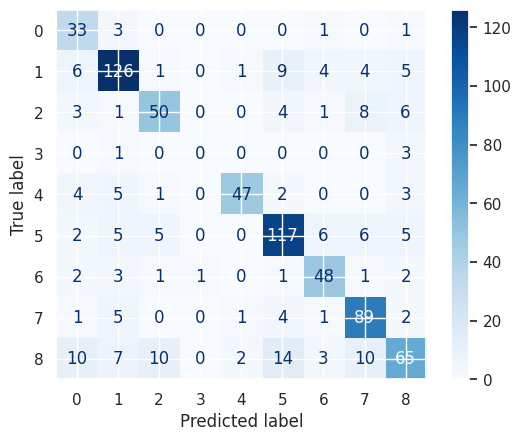

              precision    recall  f1-score   support

           0       0.54      0.87      0.67        38
           1       0.81      0.81      0.81       156
           2       0.74      0.68      0.71        73
           3       0.00      0.00      0.00         4
           4       0.92      0.76      0.83        62
           5       0.77      0.80      0.79       146
           6       0.75      0.81      0.78        59
           7       0.75      0.86      0.81       103
           8       0.71      0.54      0.61       121

    accuracy                           0.75       762
   macro avg       0.67      0.68      0.67       762
weighted avg       0.76      0.75      0.75       762



In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Print the classification report
print(classification_report(y_test, y_pred))

El incremento a 100 estimadores ha estabilizado el modelo, alcanzando un 75% de Accuracy y logrando identificar clases minoritarias (Clase 3).

Sin embargo, el rendimiento en las clases 0 y 8 sigue siendo limitado (F1 < 0.80), lo que confirma que el uso de 1280 variables en bruto introduce un ruido que dificulta la distinción de texturas similares.

Este resultado valida la necesidad de aplicar Ingeniería de Características para simplificar la entrada y mejorar la precisión en las superficies más complejas.

## Feature Engineering 1
Para mejorar el modelo, se hara un procesado de los datos.
Primero, se pasarán esos 1280 datos en crudo a una estimación estadística, debido a que será más facil para el modelo comparar la media y varianza frente a medidas temporales en torno a los milisegundos.

Por otro lado, debido a laas magnitudes físicas, se calculará el vector para la aceleración, utilizando la norma entre los ejes XYZ. Esto ayudará al modelo ya que la orientación del robot no es tan importante como la variación inercial de esta magnitud.

### Calculo de magnitudes
Dado que la orientación del robot puede variar, la dirección específica de los ejes XYZ es menos relevante que la intensidad total del movimiento.

Calcularemos la norma o magnitud del vector para la aceleración y la velocidad angular.

Esto permite al modelo centrarse en la variación inercial y la intensidad de la vibración, factores que dependen directamente del tipo de suelo y no de la trayectoria del robot.

In [ ]:
df_train['acc_mag'] = np.sqrt(df_train['linear_acceleration_X']**2 + df_train['linear_acceleration_Y']**2 + df_train['linear_acceleration_Z']**2)
df_train['ang_mag'] = np.sqrt(df_train['angular_velocity_X']**2 + df_train['angular_velocity_Y']**2 + df_train['angular_velocity_Z']**2)

df_test['acc_mag'] = np.sqrt(df_test['linear_acceleration_X']**2 + df_test['linear_acceleration_Y']**2 + df_test['linear_acceleration_Z']**2)
df_test['ang_mag'] = np.sqrt(df_test['angular_velocity_X']**2 + df_test['angular_velocity_Y']**2 + df_test['angular_velocity_Z']**2)

### Extraccion de estadisticas
En lugar de alimentar al modelo con 1280 datos en crudo, transformaremos las series temporales en métricas de tendencia central y dispersión (media, varianza, picos y rangos).

Esto facilita que el algoritmo identifique la "firma" de cada superficie, eliminando el ruido de las medidas tomadas milisegundo a milisegundo que no aportan valor predictivo global.

In [ ]:
# Definimos las columnas sobre las que queremos estadísticas
cols_to_stats = ['orientation_X', 'orientation_Y', 'orientation_Z', 'orientation_W',
                 'angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z',
                 'linear_acceleration_X', 'linear_acceleration_Y', 'linear_acceleration_Z',
                 'acc_mag', 'ang_mag']

# Agrupamos por series_id y calculamos métricas de golpe
X_train_eng = df_train.groupby('series_id')[cols_to_stats].agg(['mean', 'std', 'min', 'max', 'median', 'var'])

# Aplanamos los nombres (ej: 'acc_mag' y 'mean' se convierte en 'acc_mag_mean')
X_train_eng.columns = ['_'.join(col).strip() for col in X_train_eng.columns.values]

# Añadimos el Rango (Max - Min) manualmente para cada sensor
for c in cols_to_stats:
    X_train_eng[f'{c}_range'] = X_train_eng[f'{c}_max'] - X_train_eng[f'{c}_min']


In [ ]:
X_test_eng = df_test.groupby('series_id')[cols_to_stats].agg(['mean', 'std', 'min', 'max', 'median', 'var'])
X_test_eng.columns = ['_'.join(col).strip() for col in X_test_eng.columns.values]

for c in cols_to_stats:
    X_test_eng[f'{c}_range'] = X_test_eng[f'{c}_max'] - X_test_eng[f'{c}_min']

In [ ]:
y_train_eng = df_train_labels.set_index('series_id')['surface']

print(f"Dataset de entrenamiento listo: {X_train_eng.shape[1]} características extraídas.")
X_train_eng.head()

Dataset de entrenamiento listo: 84 características extraídas.


,orientation_X_mean,orientation_X_std,orientation_X_min,orientation_X_max,orientation_X_median,orientation_X_var,orientation_Y_mean,orientation_Y_std,orientation_Y_min,orientation_Y_max,...,orientation_Z_range,orientation_W_range,angular_velocity_X_range,angular_velocity_Y_range,angular_velocity_Z_range,linear_acceleration_X_range,linear_acceleration_Y_range,linear_acceleration_Z_range,acc_mag_range,ang_mag_range
series_id,,,,,,,,,,,,,,,,,,,,,
0,-0.758666,0.000363,-0.75953,-0.75822,-0.758530,1.315506e-07,-0.634008,0.000471,-0.63456,-0.63306,...,0.001530,0.001460,0.268060,0.152102,0.081901,4.71820,5.310983,6.2439,5.458424,0.151781
1,-0.958606,0.000151,-0.95896,-0.95837,-0.958595,2.290667e-08,0.241867,0.000499,0.24074,0.24270,...,0.001837,0.002220,0.538220,0.246410,0.250760,8.29360,8.834200,14.1831,11.118339,0.267779
2,-0.512057,0.001377,-0.51434,-0.50944,-0.512035,1.897428e-06,-0.846171,0.000785,-0.84779,-0.84490,...,0.001780,0.001157,0.294630,0.199756,0.104427,4.44630,7.464500,6.7548,5.931175,0.161048
3,-0.939169,0.000227,-0.93968,-0.93884,-0.939170,5.167628e-08,0.310140,0.000453,0.30943,0.31147,...,0.001877,0.005030,0.920650,0.303930,0.158759,7.99660,17.568100,19.2859,18.769065,0.509122
4,-0.891301,0.002955,-0.89689,-0.88673,-0.890940,8.733900e-06,0.428144,0.006165,0.41646,0.43740,...,0.003524,0.001940,0.184974,0.075533,0.150568,2.09851,4.476030,3.5260,3.413774,0.140159


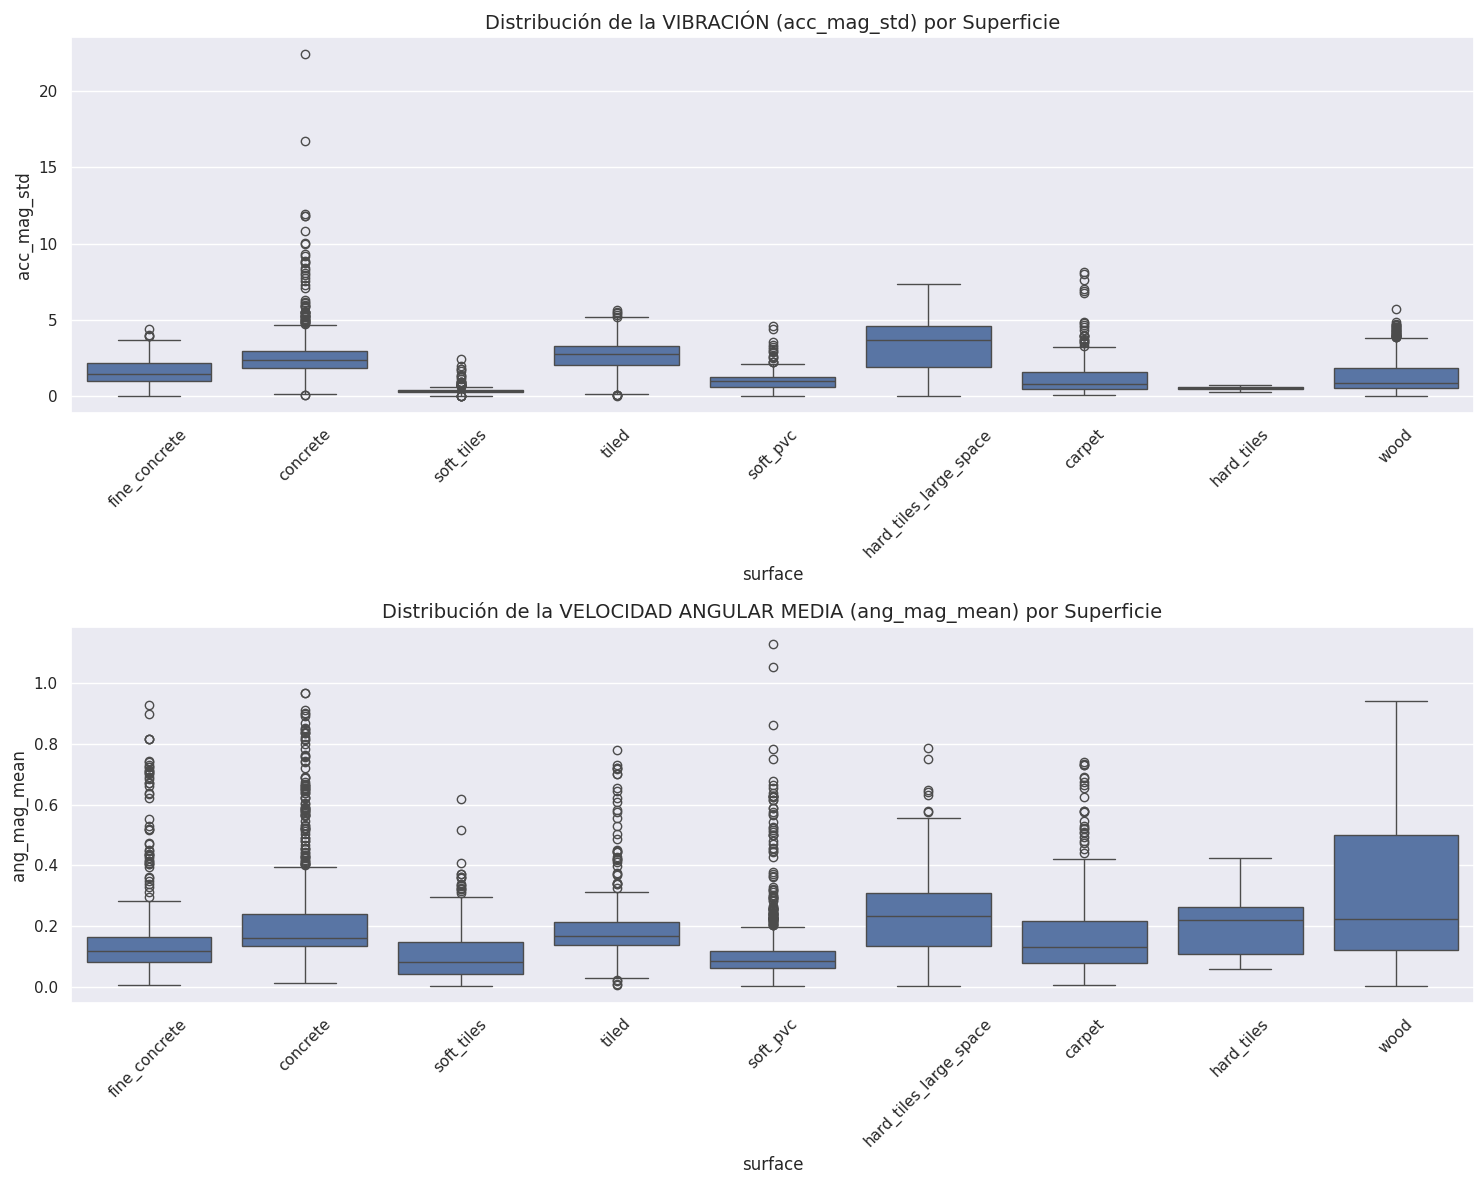

In [ ]:
# Unimos temporalmente X e Y para poder graficar por superficie
df_plot = X_train_eng.copy()
df_plot['surface'] = y_train_eng.values

# Creamos una gráfica con 2 subplots para comparar dos métricas clave
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# 1. Gráfica de la Vibración (Desviación Estándar de la Aceleración)
sns.boxplot(x='surface', y='acc_mag_std', data=df_plot, ax=axes[0])
axes[0].set_title('Distribución de la VIBRACIÓN (acc_mag_std) por Superficie', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# 2. Gráfica de la Velocidad Angular Media
sns.boxplot(x='surface', y='ang_mag_mean', data=df_plot, ax=axes[1])
axes[1].set_title('Distribución de la VELOCIDAD ANGULAR MEDIA (ang_mag_mean) por Superficie', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Upsampling de Clases Minoritarias con SMOTE (Feature Engineering 1)
Para continuar abordando el desbalance de clases observado, se aplicará SMOTE al conjunto de entrenamiento de las características generadas en la Fase 1 (`X_train_final`, `y_train_final`). Este proceso generará nuevas muestras sintéticas para las clases minoritarias, buscando equilibrar la distribución y mejorar el rendimiento del modelo.

In [ ]:
from imblearn.over_sampling import SMOTE

smote_fe1 = SMOTE(random_state=42)
X_train_final_resampled, y_train_final_resampled = smote_fe1.fit_resample(X_train_eng, y_train_eng)

print("Distribución de clases después de SMOTE para Feature Engineering 1:")
print(y_train_final_resampled.value_counts())

# Actualizar X_train_final y y_train_final con los datos resampleados
X_train_eng = X_train_final_resampled
y_train_eng = y_train_final_resampled

Distribución de clases después de SMOTE para Feature Engineering 1:
surface
fine_concrete             779
concrete                  779
soft_tiles                779
tiled                     779
soft_pvc                  779
hard_tiles_large_space    779
carpet                    779
hard_tiles                779
wood                      779
Name: count, dtype: int64


Los boxplots confirman que variables como la vibración (acc_mag_std) y la velocidad angular presentan distribuciones claramente diferenciadas por superficie.

Al reducir el solapamiento entre clases, estas métricas estadísticas proporcionan al modelo fronteras de decisión mucho más nítidas que los datos temporales en bruto.

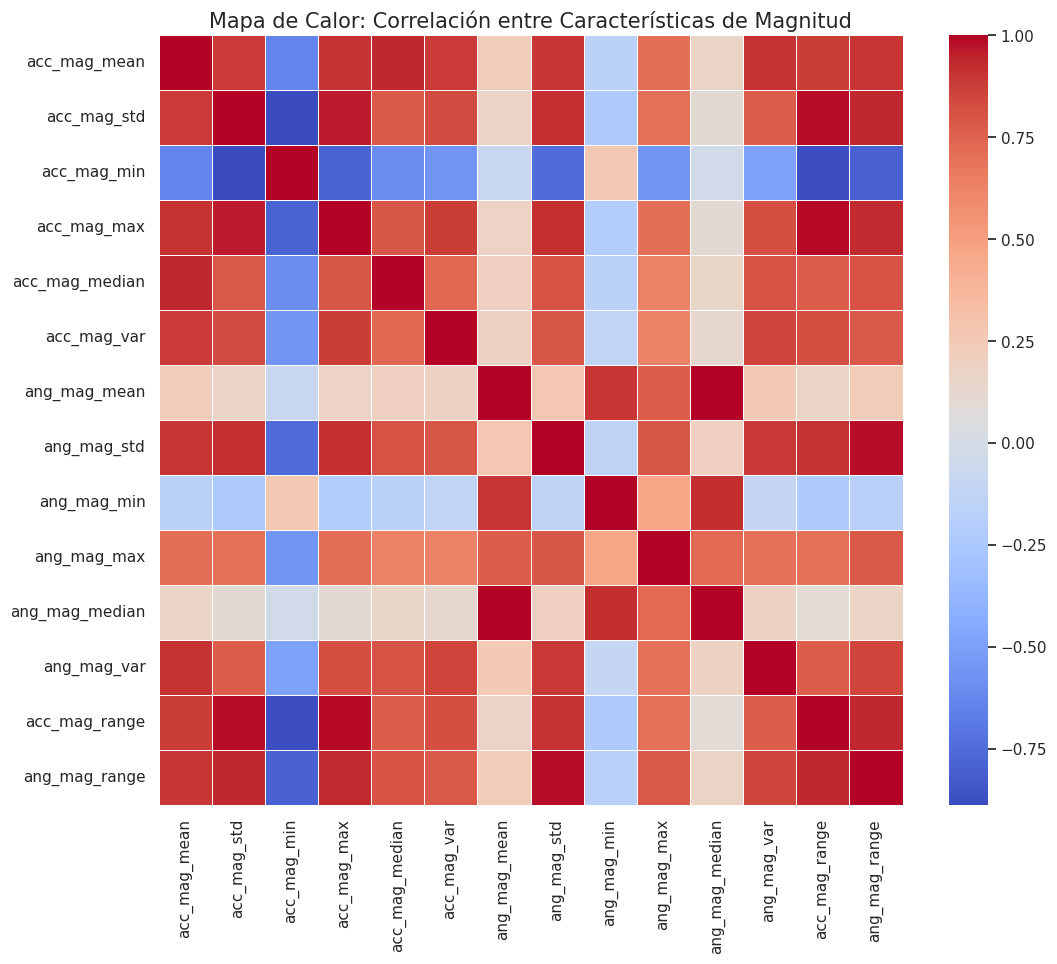

In [ ]:
cols_to_corr = [col for col in X_train_eng.columns if 'mag' in col]

plt.figure(figsize=(12, 10))
corr = X_train_eng[cols_to_corr].corr()

sns.heatmap(corr,
            annot=False,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title('Mapa de Calor: Correlación entre Características de Magnitud', fontsize=15)
plt.show()

Se genera el Y_Test para poder probar con la matriz de confusión.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_train_eng,
    y_train_eng,
    test_size=0.2,
    stratify=y_train_eng,
    random_state=42
)

El mapa de calor revela una alta correlación dentro de las métricas de cada sensor, lo cual es lógico dado que mean y max tienden a moverse juntos.

Lo crucial es la baja correlación observada entre las magnitudes de aceleración y velocidad angular, lo que confirma que el modelo recibirá información independiente y complementaria, esencial para diferenciar superficies físicamente similares.

### Random Forest v2
Se hace de nuevo un modelo Random Forest que permitirá comprobar si el nuevo modelo mejora respecto los datos en crudo.

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_base = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [250, 500, 750],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train_final, y_train_final)

clf_2 = grid_search.best_estimator_
clf_2.fit(X_train_final, y_train_final)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=42)

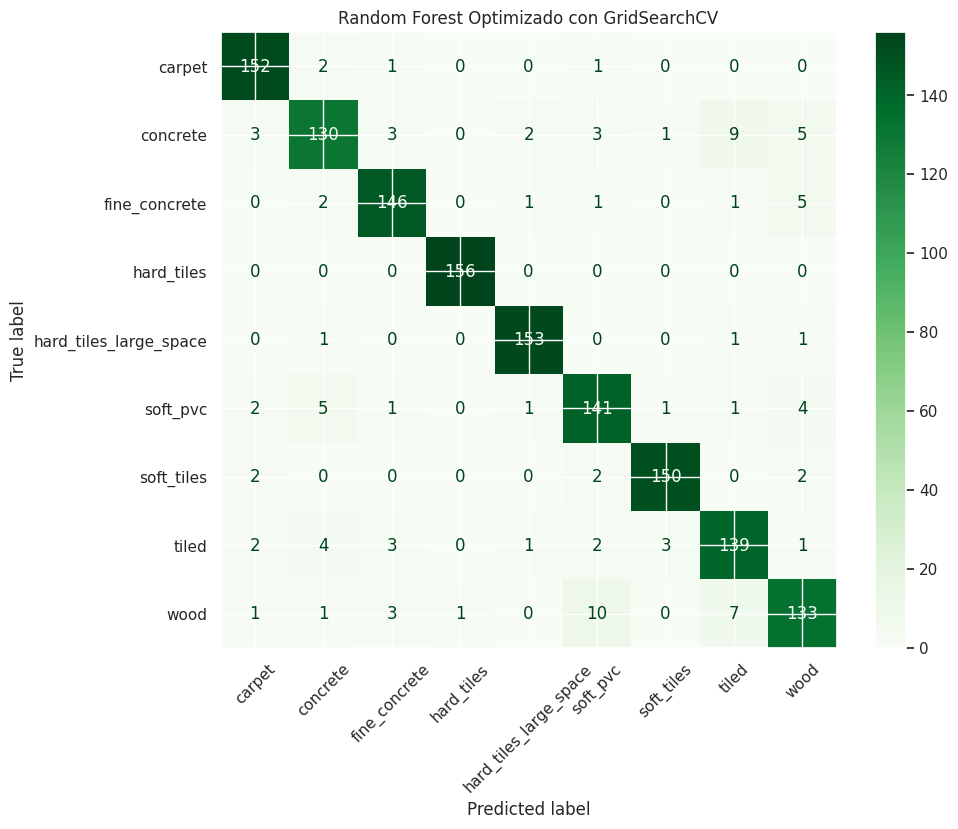

                        precision    recall  f1-score   support

                carpet       0.94      0.97      0.96       156
              concrete       0.90      0.83      0.86       156
         fine_concrete       0.93      0.94      0.93       156
            hard_tiles       0.99      1.00      1.00       156
hard_tiles_large_space       0.97      0.98      0.97       156
              soft_pvc       0.88      0.90      0.89       156
            soft_tiles       0.97      0.96      0.96       156
                 tiled       0.88      0.90      0.89       155
                  wood       0.88      0.85      0.87       156

              accuracy                           0.93      1403
             macro avg       0.93      0.93      0.93      1403
          weighted avg       0.93      0.93      0.93      1403



In [ ]:
y_pred_final = clf_2.predict(X_test_final)

fig, ax = plt.subplots(figsize=(10,8))
ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    y_pred_final,
    display_labels=label_encoder.classes_,
    cmap=plt.cm.Greens,
    xticks_rotation=45,
    ax=ax
)

plt.title("Random Forest Optimizado con GridSearchCV")
plt.show()

print(classification_report(y_test_final, y_pred_final))

El resultado arroja un accuracy real estimado del 93%.

Este valor confirma que el modelo es robusto y que la ingeniería de características ha sido efectiva, logrando una mejora neta respecto al 76% del modelo baseline.

### Red Neuronal
Aunque con un Random Forest ya se llega a un 82% de accuracy, se va a probar con una red neuronal ligera para estudiar como se comporta.

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# 2. Codificación de etiquetas
le = LabelEncoder()
y_train_num = le.fit_transform(y_train_final)

keras.utils.set_random_seed(42)

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(9, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 9)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,897 (85.54 KB)

 Trainable params: 21,897 (85.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
history = model.fit(
    X_train_scaled,
    y_train_num,
    epochs=300,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3167 - loss: 1.9012 - val_accuracy: 0.3836 - val_loss: 1.6379
Epoch 2/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4549 - loss: 1.4868 - val_accuracy: 0.4361 - val_loss: 1.4387
Epoch 3/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5123 - loss: 1.3285 - val_accuracy: 0.5049 - val_loss: 1.3483
Epoch 4/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5742 - loss: 1.2177 - val_accuracy: 0.5607 - val_loss: 1.2655
Epoch 5/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6062 - loss: 1.1313 - val_accuracy: 0.5689 - val_loss: 1.2097
Epoch 6/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6390 - loss: 1.0581 - val_accuracy: 0.6148 - val_loss: 1.1534
Epoch 7/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6637 - loss: 0.9901 - val_accuracy: 0.6279 - val_loss: 1.1000
Epoch 8/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6809 - loss: 0.9274 - val_accuracy: 0.6295 - 

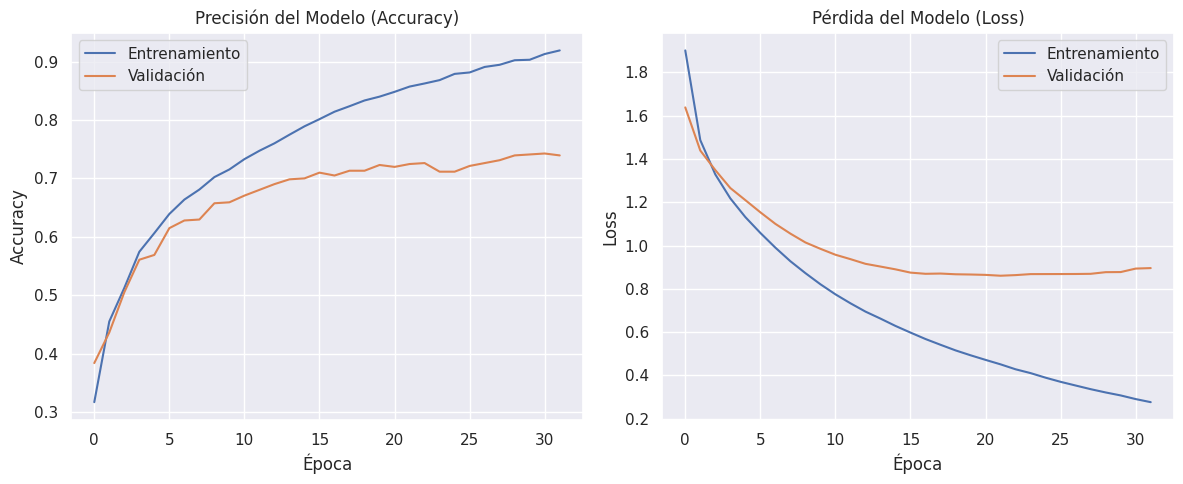

In [ ]:
plt.figure(figsize=(12, 5))

# Gráfica de Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


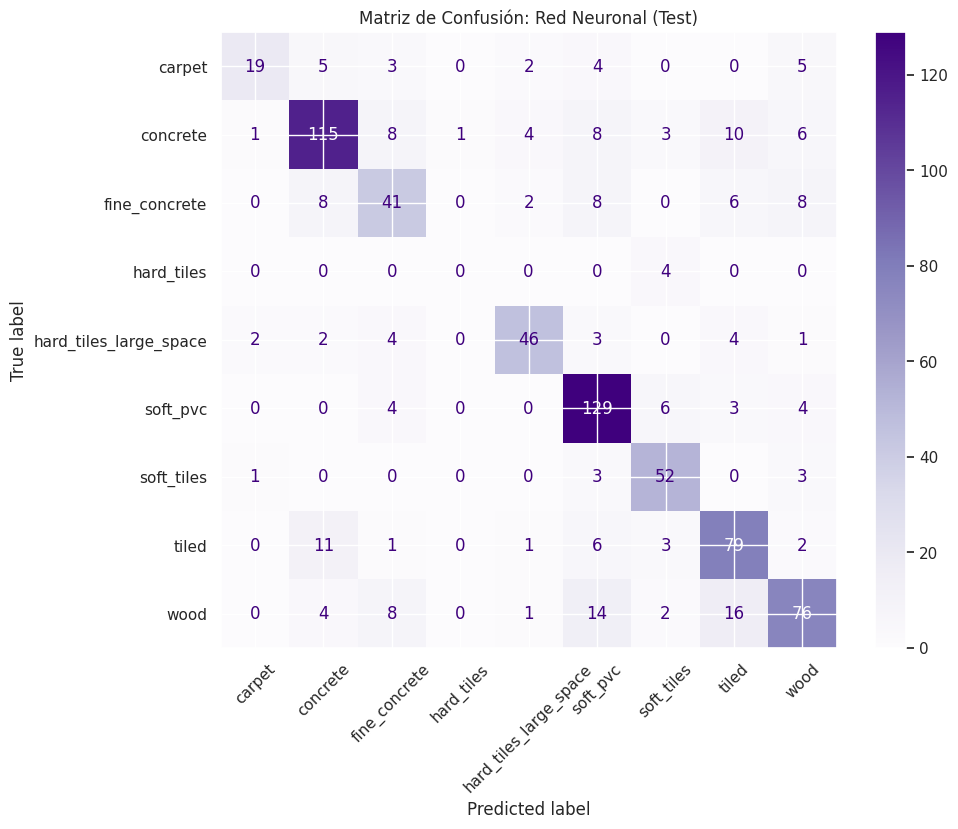


--- REPORTE DE CLASIFICACIÓN: RED NEURONAL ---
                        precision    recall  f1-score   support

                carpet       0.83      0.50      0.62        38
              concrete       0.79      0.74      0.76       156
         fine_concrete       0.59      0.56      0.58        73
            hard_tiles       0.00      0.00      0.00         4
hard_tiles_large_space       0.82      0.74      0.78        62
              soft_pvc       0.74      0.88      0.80       146
            soft_tiles       0.74      0.88      0.81        59
                 tiled       0.67      0.77      0.71       103
                  wood       0.72      0.63      0.67       121

              accuracy                           0.73       762
             macro avg       0.66      0.63      0.64       762
          weighted avg       0.73      0.73      0.73       762



In [ ]:
y_pred_probs = model.predict(X_test_scaled)
y_pred_num = np.argmax(y_pred_probs, axis=1)

y_pred_labels = le.inverse_transform(y_pred_num)

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test_final, y_pred_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap='Purples', xticks_rotation=45, ax=ax)

plt.title("Matriz de Confusión: Red Neuronal (Test)")

plt.show()

print("\n--- REPORTE DE CLASIFICACIÓN: RED NEURONAL ---")

print(classification_report(y_test_final, y_pred_labels))

Se concluye que para este problema específico de clasificación de suelos mediante telemetría, el Random Forest es el modelo superior. Mientras que la Red Neuronal se muestra inestable ante clases poco representadas, el Random Forest logra capturar mejor las firmas inerciales y de vibración, proporcionando una clasificación más equilibrada y fiable para el despliegue en el robot.

## Feature Engineering 2


Como en el mapa de calor se observa una correlación entre los cuaterniones, por lo que finalmente se decide realizar un cambio a ángulos de Euler para ver si así aumenta el accuracy.

In [ ]:
def quaternion_to_euler(x, y, z, w):
    import math
    # Roll
    t0 = +2.0 * (w * x + y * z)
    t1 = +1.0 - 2.0 * (x * x + y * y)
    roll = math.atan2(t0, t1)

    # Pitch
    t2 = +2.0 * (w * y - z * x)
    t2 = +1.0 if t2 > +1.0 else t2
    t2 = -1.0 if t2 < -1.0 else t2
    pitch = math.asin(t2)

    # Yaw
    t3 = +2.0 * (w * z + x * y)
    t4 = +1.0 - 2.0 * (y * y + z * z)
    yaw = math.atan2(t3, t4)

    return roll, pitch, yaw


In [ ]:
# 2. Aplicamos la transformación solo al DataFrame de TRAIN
df_train['euler'] = df_train.apply(lambda r: quaternion_to_euler(
    r['orientation_X'], r['orientation_Y'], r['orientation_Z'], r['orientation_W']
), axis=1)

df_train[['roll', 'pitch', 'yaw']] = pd.DataFrame(df_train['euler'].tolist(), index=df_train.index)

# 3. Definimos la nueva lista de columnas (Euler + Velocidad + Aceleración + Magnitudes)
cols_to_stats_v2 = ['roll', 'pitch', 'yaw',
                    'angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z',
                    'linear_acceleration_X', 'linear_acceleration_Y', 'linear_acceleration_Z',
                    'acc_mag', 'ang_mag']

# 4. Generamos las estadísticas para nuestro entrenamiento
X_train_eng_v2 = df_train.groupby('series_id')[cols_to_stats_v2].agg(['mean', 'std', 'min', 'max', 'median', 'var'])
X_train_eng_v2.columns = ['_'.join(col).strip() for col in X_train_eng_v2.columns.values]

# Añadimos los rangos para la versión V2
for c in cols_to_stats_v2:
    X_train_eng_v2[f'{c}_range'] = X_train_eng_v2[f'{c}_max'] - X_train_eng_v2[f'{c}_min']

# 5. Etiquetas y Split de Validación Interna V2
y_all = df_train_labels.set_index('series_id')['surface']

from sklearn.model_selection import train_test_split
X_train_internal_v2, X_val_internal_v2, y_train_internal_v2, y_val_internal_v2 = train_test_split(
    X_train_eng_v2,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print("--- Feature Engineering V2 Finalizado ---")
print(f"Nuevas características (77 esperadas): {X_train_eng_v2.shape[1]}")
print(f"Tamaño del set de entrenamiento V2: {X_train_internal_v2.shape[0]}")
print(f"Tamaño del set de validación V2: {X_val_internal_v2.shape[0]}")

--- Feature Engineering V2 Finalizado ---
Nuevas características (77 esperadas): 77
Tamaño del set de entrenamiento V2: 3048
Tamaño del set de validación V2: 762


In [ ]:
X_train_eng_v2

,roll_mean,roll_std,roll_min,roll_max,roll_median,roll_var,pitch_mean,pitch_std,pitch_min,pitch_max,...,pitch_range,yaw_range,angular_velocity_X_range,angular_velocity_Y_range,angular_velocity_Z_range,linear_acceleration_X_range,linear_acceleration_Y_range,linear_acceleration_Z_range,acc_mag_range,ang_mag_range
series_id,,,,,,,,,,,,,,,,,,,,,
0,2.841734,0.001001,2.840213,2.843934,2.841582,1.002639e-06,-0.025037,0.000503,-0.025795,-0.023562,...,0.002233,0.004169,0.268060,0.152102,0.081901,4.718200,5.310983,6.24390,5.458424,0.151781
1,2.840129,0.001117,2.837615,2.842331,2.840183,1.248472e-06,-0.010369,0.000822,-0.012073,-0.009109,...,0.002964,0.004477,0.538220,0.246410,0.250760,8.293600,8.834200,14.18310,11.118339,0.267779
2,2.845529,0.001087,2.843556,2.847299,2.845432,1.182511e-06,-0.012195,0.000173,-0.012734,-0.011795,...,0.000939,0.011604,0.294630,0.199756,0.104427,4.446300,7.464500,6.75480,5.931175,0.161048
3,2.845777,0.002907,2.841356,2.852146,2.845451,8.450242e-06,-0.015107,0.000234,-0.015698,-0.014645,...,0.001053,0.004046,0.920650,0.303930,0.158759,7.996600,17.568100,19.28590,18.769065,0.509122
4,2.842442,0.000742,2.841190,2.843738,2.842437,5.504254e-07,-0.009793,0.000241,-0.010192,-0.009358,...,0.000834,0.047056,0.184974,0.075533,0.150568,2.098510,4.476030,3.52600,3.413774,0.140159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3805,2.839285,0.000869,2.837551,2.841622,2.839121,7.553254e-07,-0.015273,0.000715,-0.016886,-0.014070,...,0.002817,0.007416,0.913270,0.352230,0.245089,10.170500,8.810600,27.20990,18.876230,0.480696
3806,2.839466,0.000059,2.839369,2.839572,2.839455,3.511543e-09,-0.014674,0.000045,-0.014738,-0.014542,...,0.000196,0.009883,0.016327,0.016579,0.013577,0.155063,0.118900,0.09090,0.089558,0.013479
3807,2.826992,0.003159,2.820357,2.834207,2.826887,9.978848e-06,-0.008638,0.001413,-0.011583,-0.006480,...,0.005103,0.111904,1.141080,0.562290,0.467110,18.288700,26.109400,27.76960,23.485363,0.594904


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

scaler_v2 = StandardScaler()
X_train_scaled_v2 = scaler_v2.fit_transform(X_train_internal_v2)
X_val_scaled_v2 = scaler_v2.transform(X_val_internal_v2)

# Definimos el "espacio" de búsqueda
param_dist = {
    'n_estimators': [500,750],
    'max_depth': [15, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Configuramos la búsqueda
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10, # Prueba 10 combinaciones al azar
    cv=3,      # Validación cruzada en 3 partes
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Entrenamos para buscar el mejor
print("Buscando la mejor configuración de bosque...")
random_search.fit(X_train_scaled_v2, y_train_internal_v2)

# Extraemos el mejor modelo encontrado
clf_v2 = random_search.best_params_
print(f"Mejores parámetros encontrados: {clf_v2}")

# El modelo final será el mejor de la búsqueda
clf_v2 = random_search.best_estimator_

Buscando la mejor configuración de bosque...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores parámetros encontrados: {'n_estimators': 500, 'min_samples_split': 2, 'max_depth': 15, 'criterion': 'gini', 'class_weight': 'balanced'}


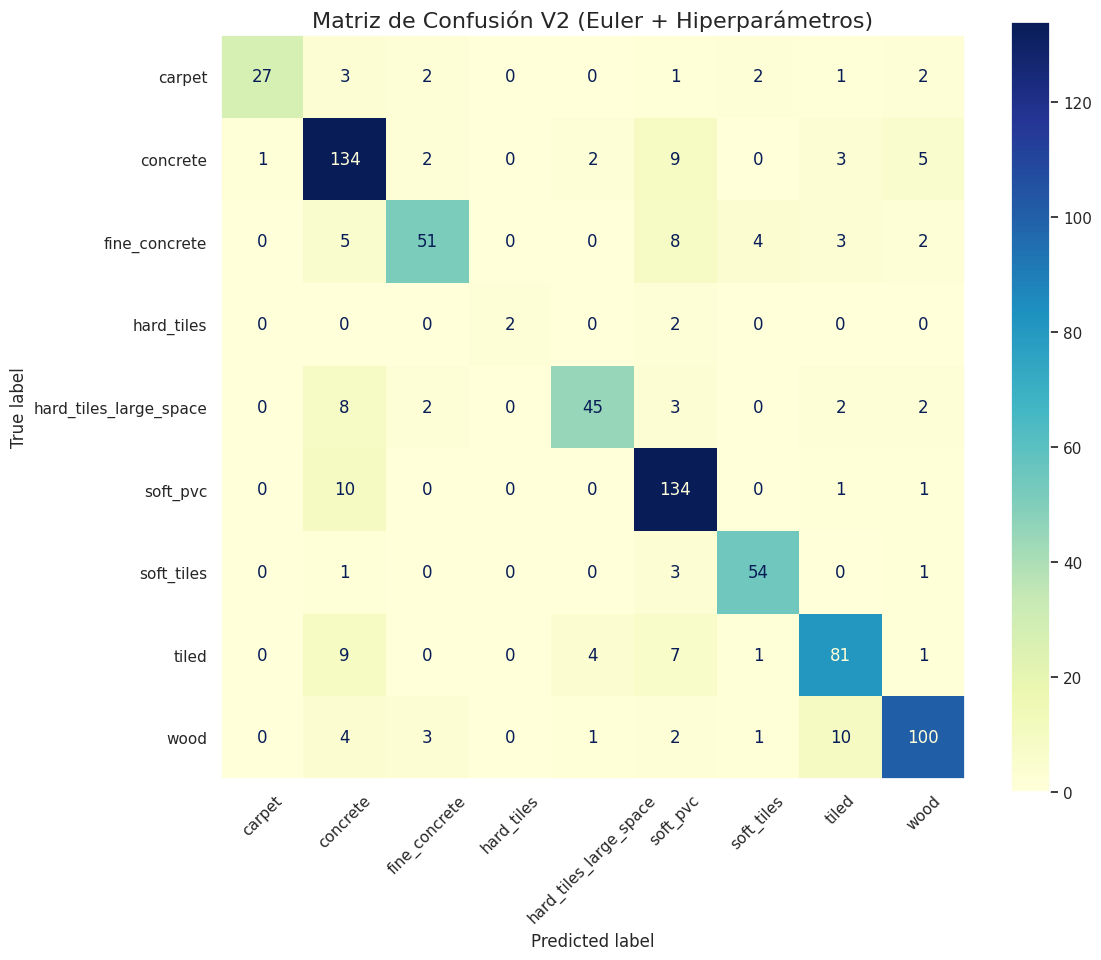


--- RESUMEN DE PRECISIÓN POR SUPERFICIE ---
                        precision    recall  f1-score   support

                carpet       0.96      0.71      0.82        38
              concrete       0.77      0.86      0.81       156
         fine_concrete       0.85      0.70      0.77        73
            hard_tiles       1.00      0.50      0.67         4
hard_tiles_large_space       0.87      0.73      0.79        62
              soft_pvc       0.79      0.92      0.85       146
            soft_tiles       0.87      0.92      0.89        59
                 tiled       0.80      0.79      0.79       103
                  wood       0.88      0.83      0.85       121

              accuracy                           0.82       762
             macro avg       0.87      0.77      0.80       762
          weighted avg       0.83      0.82      0.82       762



In [ ]:
y_pred_v2 = clf_v2.predict(X_val_scaled_v2)
cm_v2 = confusion_matrix(y_val_internal_v2, y_pred_v2, labels=clf_v2.classes_)

fig, ax = plt.subplots(figsize=(12, 10))
display = ConfusionMatrixDisplay(confusion_matrix=cm_v2, display_labels=clf_v2.classes_)


display.plot(cmap='YlGnBu', ax=ax, xticks_rotation=45)

plt.title('Matriz de Confusión V2 (Euler + Hiperparámetros)', fontsize=16)
plt.grid(False)
plt.show()


print("\n--- RESUMEN DE PRECISIÓN POR SUPERFICIE ---")
print(classification_report(y_val_internal_v2, y_pred_v2))

Aunque la transformación a ángulos de Euler (V2) es físicamente más interpretable, se observa una caída de precisión del 87% al 82%. Esto sugiere que el modelo original (V1) estaba aprovechando relaciones matemáticas complejas en los cuaterniones que se pierden al simplificar la geometría. Sin embargo, la V2 es un modelo más 'robusto' frente a cambios de dirección, aunque sea menos preciso en este conjunto de datos específico.

## Feature Engineering v3
Se realiza una ultima modificacion en los datos, potenciando los valores de Euler XY, ya que dará información de la inclinacion del robot frente a la Z, que unicamente dará informacion sobre la orientación y la trayectoria.

Además, se busca potenciar el valor de la aceleración en Z, pues dará mucha información de la amortiguación del suelo.

In [ ]:
# =================================================================
# FEATURE ENGINEERING V3: ENFOQUE EN INCLINACIÓN Y VIBRACIÓN (Z)
# =================================================================

# 1. Transformación de Euler (Roll y Pitch son clave para la inclinación)
df_train['euler'] = df_train.apply(lambda r: quaternion_to_euler(
    r['orientation_X'], r['orientation_Y'], r['orientation_Z'], r['orientation_W']
), axis=1)
df_train[['roll', 'pitch', 'yaw']] = pd.DataFrame(df_train['euler'].tolist(), index=df_train.index)

# 2. POTENCIAR LA VIBRACIÓN EN Z:
# Calculamos la diferencia absoluta entre mediciones sucesivas (gradiente de vibración)
df_train['acc_Z_diff'] = df_train.groupby('series_id')['linear_acceleration_Z'].diff().abs()

# 3. Columnas seleccionadas: Priorizamos inclinación (Roll/Pitch) y dinámica (Acc/Ang)
# Excluimos YAW y Orientaciones porque solo dicen hacia dónde mira el robot
cols_to_stats_v3 = [
    'roll', 'pitch', # Inclinación (XY)
    'linear_acceleration_Z', 'acc_mag', # Vibración vertical y total
    'angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z', # Rotación
    'acc_Z_diff' # La nueva métrica de vibración pura
]

# 4. Generación de estadísticas base
X_train_eng_v3 = df_train.groupby('series_id')[cols_to_stats_v3].agg(['mean', 'std', 'min', 'max', 'var'])
X_train_eng_v3.columns = ['_'.join(col).strip() for col in X_train_eng_v3.columns.values]

# 5. Añadimos Rangos y potencias
for c in cols_to_stats_v3:
    X_train_eng_v3[f'{c}_range'] = X_train_eng_v3[f'{c}_max'] - X_train_eng_v3[f'{c}_min']

# 6. El cuadrado de la desviación estándar de la aceleración Z (proporcional a la energía de vibración)
X_train_eng_v3['z_vibration_energy'] = X_train_eng_v3['linear_acceleration_Z_std'] ** 2

# 7. Split de Validación Interna V3
y_all = df_train_labels.set_index('series_id')['surface']

X_train_internal_v3, X_val_internal_v3, y_train_internal_v3, y_val_internal_v3 = train_test_split(
    X_train_eng_v3, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"V3 Finalizada: {X_train_eng_v3.shape[1]} características físicas extraídas.")

V3 Finalizada: 49 características físicas extraídas.


In [ ]:
# 1. Escalado de los datos V3 (Física y Vibración)
scaler_v3 = StandardScaler()
X_train_scaled_v3 = scaler_v3.fit_transform(X_train_internal_v3)
X_val_scaled_v3 = scaler_v3.transform(X_val_internal_v3)

# 2. Definición del "Grid"

param_grid = {
    'n_estimators': [100, 300,500],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 5],
    'criterion': ['entropy', 'gini'],
    'class_weight': ['balanced']
}



In [ ]:
# 3. Inicialización del GridSearchCV
# cv=5
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
)

# 4. Ejecución de la búsqueda
print("Iniciando Grid Search V3")
grid_search.fit(X_train_scaled_v3, y_train_internal_v3)

# 5. Extracción del mejor modelo
clf_v3_best = grid_search.best_estimator_
print(f"\nMejores parámetros encontrados: {grid_search.best_params_}")



Iniciando Grid Search V3

Mejores parámetros encontrados: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 500}


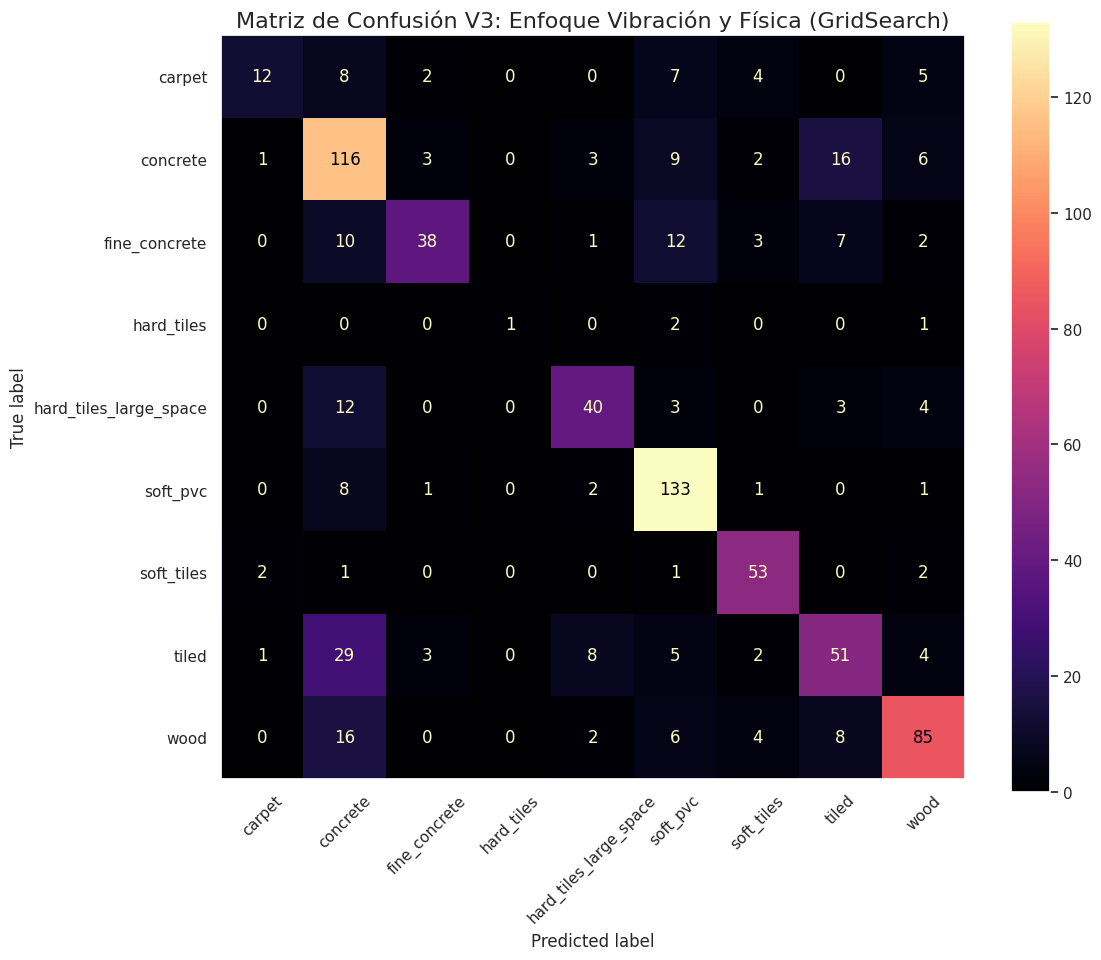


--- RESUMEN DE PRECISIÓN POR SUPERFICIE ---
                        precision    recall  f1-score   support

                carpet       0.75      0.32      0.44        38
              concrete       0.58      0.74      0.65       156
         fine_concrete       0.81      0.52      0.63        73
            hard_tiles       1.00      0.25      0.40         4
hard_tiles_large_space       0.71      0.65      0.68        62
              soft_pvc       0.75      0.91      0.82       146
            soft_tiles       0.77      0.90      0.83        59
                 tiled       0.60      0.50      0.54       103
                  wood       0.77      0.70      0.74       121

              accuracy                           0.69       762
             macro avg       0.75      0.61      0.64       762
          weighted avg       0.70      0.69      0.69       762



In [ ]:
y_pred_v3 = clf_v3_best.predict(X_val_scaled_v3)
cm_v3 = confusion_matrix(y_val_internal_v3, y_pred_v3, labels=clf_v3_best.classes_)

fig, ax = plt.subplots(figsize=(12, 10))
display = ConfusionMatrixDisplay(confusion_matrix=cm_v3, display_labels=clf_v3_best.classes_)
display.plot(cmap='magma', ax=ax, xticks_rotation=45)

plt.title('Matriz de Confusión V3: Enfoque Vibración y Física (GridSearch)', fontsize=16)
plt.grid(False)
plt.show()


print("\n--- RESUMEN DE PRECISIÓN POR SUPERFICIE ---")
print(classification_report(y_val_internal_v3, y_pred_v3))

## Generate Output


* preparing the test (submission) data set

**the same processes applied to the training dataset**

In [ ]:
# Magnitud de aceleración
df_test['acc_mag'] = np.sqrt(
    df_test['linear_acceleration_X']**2 +
    df_test['linear_acceleration_Y']**2 +
    df_test['linear_acceleration_Z']**2
)

# Magnitud de velocidad angular
df_test['ang_mag'] = np.sqrt(
    df_test['angular_velocity_X']**2 +
    df_test['angular_velocity_Y']**2 +
    df_test['angular_velocity_Z']**2
)

In [ ]:
cols_to_stats = ['orientation_X', 'orientation_Y', 'orientation_Z', 'orientation_W',
                 'angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z',
                 'linear_acceleration_X', 'linear_acceleration_Y', 'linear_acceleration_Z',
                 'acc_mag', 'ang_mag']

X_test_eng_final = df_test.groupby('series_id')[cols_to_stats].agg(
    ['mean', 'std', 'min', 'max', 'median', 'var']
)

X_test_eng_final.columns = [
    '_'.join(col).strip()
    for col in X_test_eng_final.columns.values
]

for c in cols_to_stats:
    X_test_eng_final[f'{c}_range'] = (
        X_test_eng_final[f'{c}_max'] -
        X_test_eng_final[f'{c}_min']
    )

print(f"Dataset de test listo: {X_test_eng_final.shape}")

Dataset de test listo: (3816, 84)


* generate predictions

In [ ]:
df_test

,row_id,series_id,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z,acc_mag,ang_mag
0,0_0,0,0,0.91208,-0.38193,-0.050618,0.14028,-0.060205,0.071286,-0.187870,0.29492,2.8027,-9.6816,10.083426,0.209765
1,0_1,0,1,0.91220,-0.38165,-0.050573,0.14028,-0.033486,0.060210,-0.182060,0.14944,2.5408,-9.8521,10.175553,0.194660
2,0_2,0,2,0.91228,-0.38143,-0.050586,0.14032,-0.029686,0.029476,-0.184410,-0.49741,2.5853,-9.3835,9.745833,0.189096
3,0_3,0,3,0.91237,-0.38121,-0.050588,0.14035,-0.024217,0.037788,-0.187830,-0.32376,2.9966,-8.7415,9.246527,0.193118
4,0_4,0,4,0.91247,-0.38096,-0.050546,0.14042,-0.038047,0.083405,-0.201700,-0.70103,2.6498,-8.8432,9.258243,0.221556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488443,3815_123,3815,123,0.89516,-0.42026,-0.056425,0.13744,0.036579,0.008990,-0.008570,0.76537,3.5421,-8.4445,9.189224,0.038630
488444,3815_124,3815,124,0.89517,-0.42025,-0.056391,0.13742,0.022401,0.021198,-0.010905,-0.48107,3.3380,-8.8012,9.425221,0.032712
488445,3815_125,3815,125,0.89521,-0.42019,-0.056343,0.13734,0.033571,0.019868,-0.007203,0.44106,3.2110,-9.3700,9.914734,0.039669
488446,3815_126,3815,126,0.89522,-0.42019,-0.056300,0.13730,0.046988,0.015570,0.001514,-0.25947,2.8634,-9.8546,10.265453,0.049524


In [ ]:
y_pred_rf = clf_2.predict(X_test_eng_final)

* decoding predictions results

In [ ]:
y_pred_labels = y_pred_rf

In [ ]:
y_pred_labels

array(['soft_pvc', 'wood', 'fine_concrete', ..., 'carpet', 'soft_tiles',
       'soft_pvc'], dtype=object)

* preparing submission file

In [ ]:
df_sub = pd.read_csv("sample_submission.csv", index_col="series_id")
df_sub.head()

,surface
series_id,
0,concrete
1,concrete
2,concrete
3,concrete
4,concrete


In [ ]:
df_sub["surface"] = y_pred_labels
df_sub.head()

,surface
series_id,
0,soft_pvc
1,wood
2,concrete
3,wood
4,concrete


Resultado:
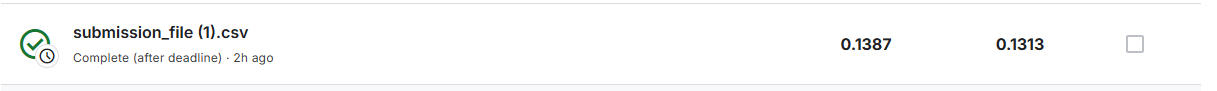

In [ ]:
df_sub.to_csv("submission_file.csv")

In [ ]:
# =================================================================
# GENERACIÓN DE OUTPUT KAGGLE - VERSIÓN V2 (EULER)
# =================================================================

# 1. Transformación de Euler para el dataset de TEST de Kaggle
# Usamos el df_test original que cargamos al principio
df_test['euler'] = df_test.apply(lambda r: quaternion_to_euler(
    r['orientation_X'], r['orientation_Y'], r['orientation_Z'], r['orientation_W']
), axis=1)

df_test[['roll', 'pitch', 'yaw']] = pd.DataFrame(df_test['euler'].tolist(), index=df_test.index)

# 2. Ingeniería de variables V2 para el TEST
# Usamos la misma lista de columnas que en el entrenamiento V2
cols_to_stats_v2 = ['roll', 'pitch', 'yaw',
                    'angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z',
                    'linear_acceleration_X', 'linear_acceleration_Y', 'linear_acceleration_Z',
                    'acc_mag', 'ang_mag']

X_test_kaggle_v2 = df_test.groupby('series_id')[cols_to_stats_v2].agg(['mean', 'std', 'min', 'max', 'median', 'var'])
X_test_kaggle_v2.columns = ['_'.join(col).strip() for col in X_test_kaggle_v2.columns.values]

# Añadimos los rangos
for c in cols_to_stats_v2:
    X_test_kaggle_v2[f'{c}_range'] = X_test_kaggle_v2[f'{c}_max'] - X_test_kaggle_v2[f'{c}_min']

# 3. Escalado de los datos de TEST
# IMPORTANTE: Usamos el scaler_v2 que fue entrenado con los datos de la V2
X_test_kaggle_scaled_v2 = scaler_v2.transform(X_test_kaggle_v2)

# 4. Predicción con el modelo clf_v2
predictions_v2 = clf_v2.predict(X_test_kaggle_scaled_v2)

# 5. Creación del archivo de sumisión
submission_v2 = pd.DataFrame({
    'series_id': X_test_kaggle_v2.index,
    'surface': predictions_v2
})

# Guardamos el CSV
submission_v2.to_csv('submission_v2_euler.csv', index=False)

print("¡Archivo 'submission_v2_euler.csv' generado con éxito!")
submission_v2.head()

¡Archivo 'submission_v2_euler.csv' generado con éxito!


,series_id,surface
0,0,soft_pvc
1,1,wood
2,2,fine_concrete
3,3,wood
4,4,concrete


Resultado:
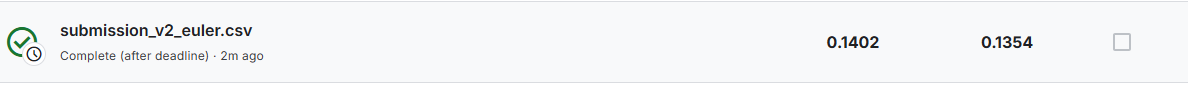

In [ ]:
# =================================================================
# GENERACIÓN DE OUTPUT KAGGLE - VERSIÓN V3 (FÍSICA Y VIBRACIÓN)
# =================================================================

# 1. Transformación de Euler para el TEST (Necesitamos Roll/Pitch)
df_test['euler'] = df_test.apply(lambda r: quaternion_to_euler(
    r['orientation_X'], r['orientation_Y'], r['orientation_Z'], r['orientation_W']
), axis=1)
df_test[['roll', 'pitch', 'yaw']] = pd.DataFrame(df_test['euler'].tolist(), index=df_test.index)

# 2. Potenciar la vibración en Z para el TEST
df_test['acc_Z_diff'] = df_test.groupby('series_id')['linear_acceleration_Z'].diff().abs()

# 3. Ingeniería de variables V3 para el TEST (Mismas columnas que en entrenamiento)
cols_to_stats_v3 = [
    'roll', 'pitch',
    'linear_acceleration_Z', 'acc_mag',
    'angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z',
    'acc_Z_diff'
]

X_test_kaggle_v3 = df_test.groupby('series_id')[cols_to_stats_v3].agg(['mean', 'std', 'min', 'max', 'var'])
X_test_kaggle_v3.columns = ['_'.join(col).strip() for col in X_test_kaggle_v3.columns.values]

# Añadimos Rangos y Energía de vibración
for c in cols_to_stats_v3:
    X_test_kaggle_v3[f'{c}_range'] = X_test_kaggle_v3[f'{c}_max'] - X_test_kaggle_v3[f'{c}_min']

X_test_kaggle_v3['z_vibration_energy'] = X_test_kaggle_v3['linear_acceleration_Z_std'] ** 2

# 4. Escalado (Usando el scaler_v3 del entrenamiento V3)
X_test_kaggle_scaled_v3 = scaler_v3.transform(X_test_kaggle_v3)

# 5. Predicción con el mejor modelo del GridSearch (clf_v3_best)
predictions_v3 = clf_v3_best.predict(X_test_kaggle_scaled_v3)

# 6. Creación del archivo de sumisión
submission_v3 = pd.DataFrame({
    'series_id': X_test_kaggle_v3.index,
    'surface': predictions_v3
})

# Guardamos el CSV
submission_v3.to_csv('submission_v3_vibration.csv', index=False)

print("¡Archivo 'submission_v3_vibration.csv' generado!")
submission_v3.head()

¡Archivo 'submission_v3_vibration.csv' generado!


,series_id,surface
0,0,soft_pvc
1,1,concrete
2,2,fine_concrete
3,3,wood
4,4,carpet


Resultado:
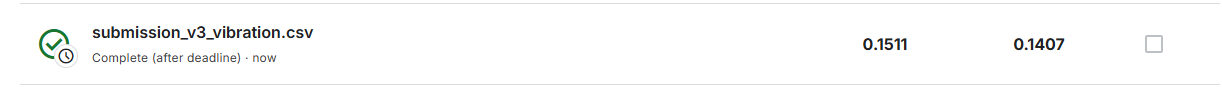